# IMDB Sentiment Classification: LSTM vs BERT

This project compares an LSTM baseline with a BERT-based transfer learning model for binary sentiment classification on IMDB movie reviews.

Key result: BERT substantially outperformed the LSTM baseline on validation and test performance.

In [ ]:
# load standard modules/libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# load special modules/libraries
import os
import warnings
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from collections import Counter
import string
import re
from tqdm  import tqdm

# load pytorch modules/libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# download IMDB review data

# load dataset
df = pd.read_csv("IMDB Dataset.csv")

# process into data and labels
X = df['review'].values
y = df['sentiment'].values


In [ ]:
positive_reviews = df[df['sentiment'] == 'positive']
negative_reviews = df[df['sentiment'] == 'negative']

print("POSITIVE REVIEW EXAMPLE ")
positive_example = positive_reviews['review'].iloc[5]  # Using index 5 for a representative sample
print(f"Length: {len(positive_example)} characters")


POSITIVE REVIEW EXAMPLE 
Length: 2519 characters


In [ ]:
# Display first 500 characters
print(positive_example[:500])

# Or display the full review
print(positive_example)

# Or display first few sentences
sentences = positive_example.split('.')
print('.'.join(sentences[:3]) + '.')  # First 3 sentences

Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV really caught my attention- and it helped that I was just writing an essay on Inferno! But let me see what HASN'T been discussed yet...<br /><br />A TWOP review mentioned that Tony had 7 flights of stairs to go down because of the broken elevator. Yeah, 7 is a significant number for lots of reasons
Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV really caught my attention- and it helped that I was just writing an essay on Inferno! But let me see what HASN'T been discussed yet...<br /><br />A TWOP review mentioned that Tony had 7 flights of stairs to go down because of the broken elevator. Yeah, 7 is a significant number for lots of reason

In [ ]:
print(" NEGATIVE REVIEW EXAMPLE ")
negative_example = negative_reviews['review'].iloc[5]  # Using index 5 for a representative sample
print(f"Length: {len(negative_example)} characters")




 NEGATIVE REVIEW EXAMPLE 
Length: 911 characters


In [ ]:
# Display first 500 characters
print(negative_example[:500])

# Or display the full review
print(negative_example)

# Or display first few sentences
sentences = negative_example.split('.')
print('.'.join(sentences[:3]) + '.')  # First 3 sentences

It's made in 2007 and the CG is bad for a movie made in 1998. At one part in the movie there is a stop motion shot of a dinosaur that actually looks good, but this just makes the extremely amateur work on the CG stuff look even worse.<br /><br />The writing, acting, directing and everything else in this movie is just terrible. This is as bad as, if not worse than Raptor Island and 100 million BC... pure crap! Again, as with the other movies, the only scary part about this movie is that it actual
It's made in 2007 and the CG is bad for a movie made in 1998. At one part in the movie there is a stop motion shot of a dinosaur that actually looks good, but this just makes the extremely amateur work on the CG stuff look even worse.<br /><br />The writing, acting, directing and everything else in this movie is just terrible. This is as bad as, if not worse than Raptor Island and 100 million BC... pure crap! Again, as with the other movies, the only scary part about this movie is that it actua

Average word count: 231.4
Shortest review: 6 words
Longest review: 2470 words
Positive reviews: 20004
Negative reviews: 19996
Positive avg words: 233.0
Negative avg words: 229.9


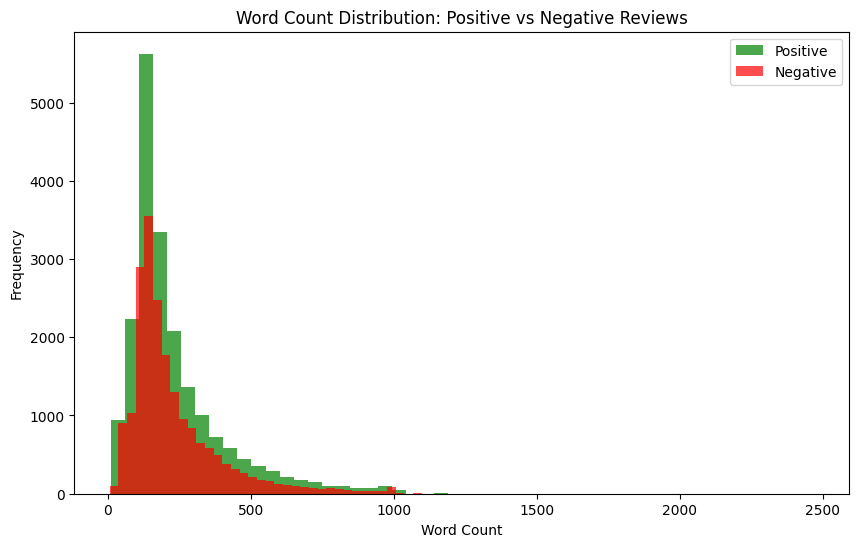

In [ ]:



# Calculate word counts
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Basic statistics
print(f"Average word count: {df['word_count'].mean():.1f}")
print(f"Shortest review: {df['word_count'].min()} words")
print(f"Longest review: {df['word_count'].max()} words")

# Count by sentiment
positive_count = (df['sentiment'] == 'positive').sum()
negative_count = (df['sentiment'] == 'negative').sum()
print(f"Positive reviews: {positive_count}")
print(f"Negative reviews: {negative_count}")

# Statistics by sentiment
positive_words = df[df['sentiment'] == 'positive']['word_count']
negative_words = df[df['sentiment'] == 'negative']['word_count']
print(f"Positive avg words: {positive_words.mean():.1f}")
print(f"Negative avg words: {negative_words.mean():.1f}")

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(positive_words, bins=50, alpha=0.7, label='Positive', color='green')
plt.hist(negative_words, bins=50, alpha=0.7, label='Negative', color='red')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Word Count Distribution: Positive vs Negative Reviews')
plt.legend()
plt.show()


In [ ]:
def preprocess_string(str1):
    # remove all non-word characters excluding number and letters
    str1= re.sub(r"[^\w\s]",'',str1)
    # remove all whitespace with no space
    str1= re.sub(r"\s",'',str1)
    # replace digits with no space
    str1= re.sub(r"\d",'',str1)
    return str1

def preprocess_sentence(sen1):
    word_list=[]
    stop_word = set(stopwords.words("english"))
    for word in sen1.lower().split():
        word = preprocess_string(word)
        if word not in stop_word and word!='':
            word_list.append(word)
    return word_list

def get_stoi(data):
    word_list=[]
    for review in data:
        word_list.extend(preprocess_sentence(review))
    corpus = Counter(word_list)
    print(corpus.get)
    # sorting on the basis of most common words
    corpus_ =sorted(corpus,key= corpus.get,reverse=True)[:1000]
    # creating a dict
    stoi =  {ch:i+1 for i,ch in enumerate(corpus_)}
    return stoi

def tokenize(data, labels, stoi):
    # tokenize
    data_encoded = []
    for review in data:
        data_encoded.append([stoi[word] for word in preprocess_sentence(review)
                             if word in stoi.keys()])

    labels_encoded = [1 if label =='positive' else 0 for label in labels]

    return np.array(data_encoded, dtype=object), np.array(labels_encoded)

def padding_(sentences, seq_len):
    features = np.zeros((len(sentences), seq_len),dtype=int)
    for ii, review in enumerate(sentences):
        if len(review)!=0:
            features[ii, -len(review):] = np.array(review)[:seq_len]

    return features

In [ ]:


# Split into train+valid and test (60-20-20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Valid: {len(X_valid)} samples")
print(f"Test: {len(X_test)} samples")

# Create vocabulary from training data
stoi = get_stoi(X_train)

# Tokenize all datasets
X_train_encoded, y_train_encoded = tokenize(X_train, y_train, stoi)
X_valid_encoded, y_valid_encoded = tokenize(X_valid, y_valid, stoi)
X_test_encoded, y_test_encoded = tokenize(X_test, y_test, stoi)

# Pad sequences to length 500
seq_len = 500
X_train_padded = padding_(X_train_encoded, seq_len)
X_valid_padded = padding_(X_valid_encoded, seq_len)
X_test_padded = padding_(X_test_encoded, seq_len)

print(f"Train shape: {X_train_padded.shape}")
print(f"Valid shape: {X_valid_padded.shape}")
print(f"Test shape: {X_test_padded.shape}")






Train: 24000 samples
Valid: 8000 samples
Test: 8000 samples
<built-in method get of Counter object at 0x7cbb3a1208c0>
Train shape: (24000, 500)
Valid shape: (8000, 500)
Test shape: (8000, 500)


In [ ]:
X_test_tensor = torch.tensor(X_test_padded)
y_test_tensor = torch.tensor(y_test_encoded)

# Create TensorDataset for test data
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoader for test data
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:




# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_padded)
y_train_tensor = torch.tensor(y_train_encoded)
X_valid_tensor = torch.tensor(X_valid_padded)
y_valid_tensor = torch.tensor(y_valid_encoded)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

# Create DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Verify DataLoader works
print("Testing DataLoader:")
for i, (batch_x, batch_y) in enumerate(train_loader):
    print(f"Batch {i+1}: X shape {batch_x.shape}, y shape {batch_y.shape}")
    if i == 2:  # Show first 3 batches
        break




Testing DataLoader:
Batch 1: X shape torch.Size([16, 500]), y shape torch.Size([16])
Batch 2: X shape torch.Size([16, 500]), y shape torch.Size([16])
Batch 3: X shape torch.Size([16, 500]), y shape torch.Size([16])


In [ ]:

#  Model Building

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size=1000, embedding_dim=128, hidden_dim=64, output_dim=1, n_layers=2, dropout=0.3):
        super(SentimentRNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size+1, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout, bidirectional=False)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 for max and mean pooling
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden=None):
        batch_size = x.size(0)

        # Embedding layer
        embedded = self.embedding(x)

        # LSTM layer
        lstm_out, hidden = self.lstm(embedded, hidden)

        # Max and average pooling
        max_pool = torch.max(lstm_out, dim=1)[0]
        avg_pool = torch.mean(lstm_out, dim=1)

        # Concatenate pooling results
        pooled = torch.cat([max_pool, avg_pool], dim=1)

        # Fully connected layer
        output = self.fc(self.dropout(pooled))

        return output, hidden

model = SentimentRNN()
print(model)

SentimentRNN(
  (embedding): Embedding(1001, 128)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print (device)

cuda


In [ ]:


def get_accuracy(model, data):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in data:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs, _ = model(batch_x)
            predictions = torch.round(torch.sigmoid(outputs)).squeeze()
            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = correct / total
    return accuracy

# Test the function
print("Model accuracy:", get_accuracy(model, valid_loader))

Model accuracy: 0.5


In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")


GPU not available.


In [ ]:





def train_model(model, train_loader, valid_loader, epochs=10, lr=0.001, patience=3):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs, _ = model(batch_x)
            loss = criterion(outputs.squeeze(), batch_y.float())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in valid_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs, _ = model(batch_x)
                loss = criterion(outputs.squeeze(), batch_y.float())
                valid_loss += loss.item()

        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_valid_loss = valid_loss / len(valid_loader)
        train_acc = get_accuracy(model, train_loader)
        valid_acc = get_accuracy(model, valid_loader)

        train_losses.append(avg_train_loss)
        valid_losses.append(avg_valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Valid Loss: {avg_valid_loss:.4f}, Valid Acc: {valid_acc:.4f}')

        # Early stopping check
        if avg_valid_loss < best_val_loss:
            best_val_loss = avg_valid_loss
            best_model_weights = model.state_dict().copy()
            patience_counter = 0
            print(f'  ↳ New best validation loss: {best_val_loss:.4f}')
        else:
            patience_counter += 1
            print(f'  ↳ No improvement for {patience_counter}/{patience} epochs')

        if patience_counter >= patience:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

    # Load best model weights
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    # Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(valid_losses, label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(valid_accs, label='Valid Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    plt.tight_layout()
    plt.show()

    return model



Epoch 1/5:
  Train Loss: 0.4671, Train Acc: 0.8645
  Valid Loss: 0.3681, Valid Acc: 0.8411
  ↳ New best validation loss: 0.3681
Epoch 2/5:
  Train Loss: 0.3423, Train Acc: 0.8905
  Valid Loss: 0.3530, Valid Acc: 0.8474
  ↳ New best validation loss: 0.3530
Epoch 3/5:
  Train Loss: 0.2984, Train Acc: 0.9114
  Valid Loss: 0.3476, Valid Acc: 0.8489
  ↳ New best validation loss: 0.3476
Epoch 4/5:
  Train Loss: 0.2547, Train Acc: 0.9328
  Valid Loss: 0.3655, Valid Acc: 0.8496
  ↳ No improvement for 1/3 epochs
Epoch 5/5:
  Train Loss: 0.2171, Train Acc: 0.9429
  Valid Loss: 0.4225, Valid Acc: 0.8424
  ↳ No improvement for 2/3 epochs


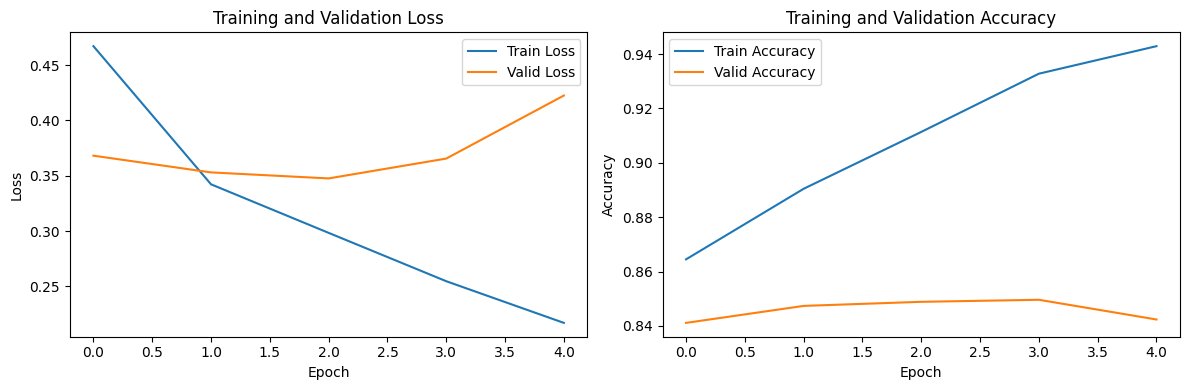

In [ ]:
# Train the model
model = SentimentRNN().to(device)
model = train_model(model, train_loader, valid_loader, epochs=5)

=== HYPERPARAMETER TUNING ===
Total models to train: 16 = 16 models

Testing: lr=0.001, hidden_dim=64, n_layers=1, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4812, Train Acc: 0.8608
  Valid Loss: 0.3749, Valid Acc: 0.8380
  ↳ New best validation loss: 0.3749
Epoch 2/15:
  Train Loss: 0.3410, Train Acc: 0.8715
  Valid Loss: 0.3681, Valid Acc: 0.8356
  ↳ New best validation loss: 0.3681
Epoch 3/15:
  Train Loss: 0.3008, Train Acc: 0.9071
  Valid Loss: 0.3428, Valid Acc: 0.8490
  ↳ New best validation loss: 0.3428
Epoch 4/15:
  Train Loss: 0.2700, Train Acc: 0.9226
  Valid Loss: 0.3494, Valid Acc: 0.8504
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2365, Train Acc: 0.9361
  Valid Loss: 0.3757, Valid Acc: 0.8474
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


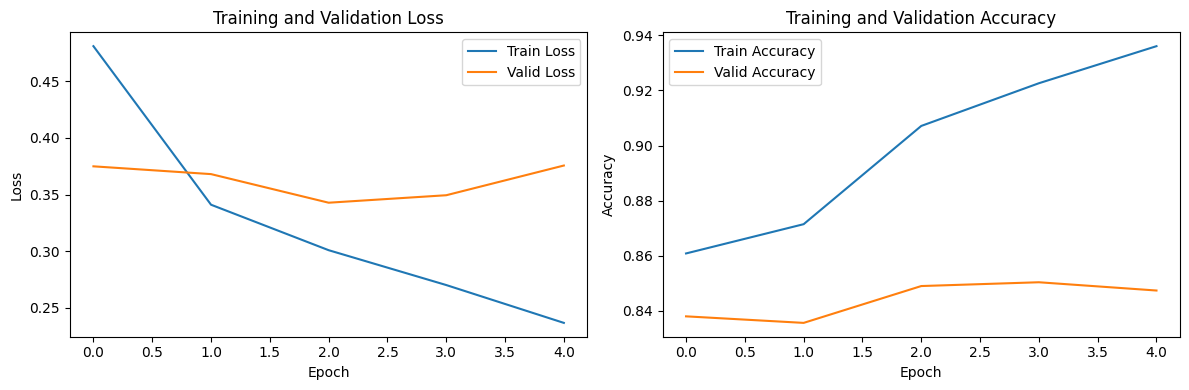

Validation Accuracy: 0.8474

Testing: lr=0.001, hidden_dim=64, n_layers=1, dropout=0.5
Epoch 1/15:
  Train Loss: 0.4936, Train Acc: 0.8630
  Valid Loss: 0.3662, Valid Acc: 0.8445
  ↳ New best validation loss: 0.3662
Epoch 2/15:
  Train Loss: 0.3574, Train Acc: 0.8767
  Valid Loss: 0.3585, Valid Acc: 0.8459
  ↳ New best validation loss: 0.3585
Epoch 3/15:
  Train Loss: 0.3176, Train Acc: 0.8895
  Valid Loss: 0.3602, Valid Acc: 0.8454
  ↳ No improvement for 1/2 epochs
Epoch 4/15:
  Train Loss: 0.2915, Train Acc: 0.9102
  Valid Loss: 0.3444, Valid Acc: 0.8511
  ↳ New best validation loss: 0.3444
Epoch 5/15:
  Train Loss: 0.2671, Train Acc: 0.9242
  Valid Loss: 0.3489, Valid Acc: 0.8498
  ↳ No improvement for 1/2 epochs
Epoch 6/15:
  Train Loss: 0.2436, Train Acc: 0.9233
  Valid Loss: 0.3856, Valid Acc: 0.8448
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 6


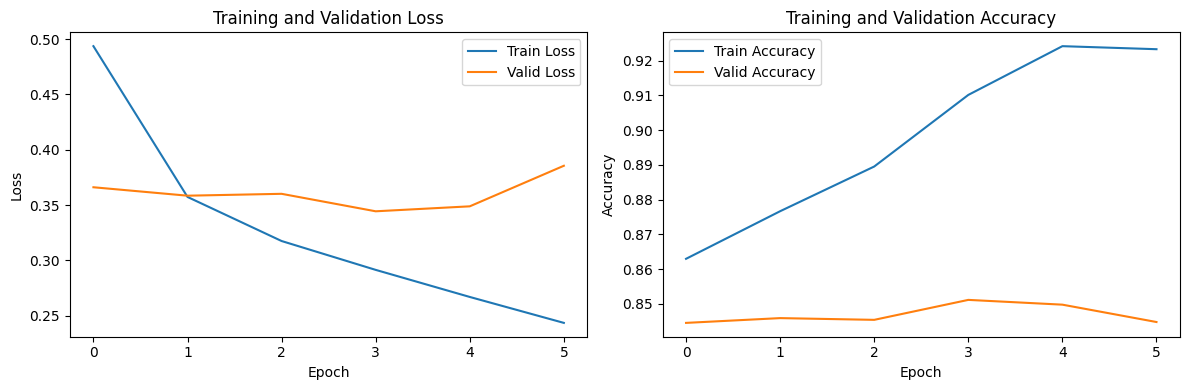

Validation Accuracy: 0.8448

Testing: lr=0.001, hidden_dim=64, n_layers=2, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4708, Train Acc: 0.8614
  Valid Loss: 0.3785, Valid Acc: 0.8355
  ↳ New best validation loss: 0.3785
Epoch 2/15:
  Train Loss: 0.3439, Train Acc: 0.8903
  Valid Loss: 0.3515, Valid Acc: 0.8468
  ↳ New best validation loss: 0.3515
Epoch 3/15:
  Train Loss: 0.3011, Train Acc: 0.9020
  Valid Loss: 0.3614, Valid Acc: 0.8436
  ↳ No improvement for 1/2 epochs
Epoch 4/15:
  Train Loss: 0.2622, Train Acc: 0.9240
  Valid Loss: 0.3662, Valid Acc: 0.8373
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 4


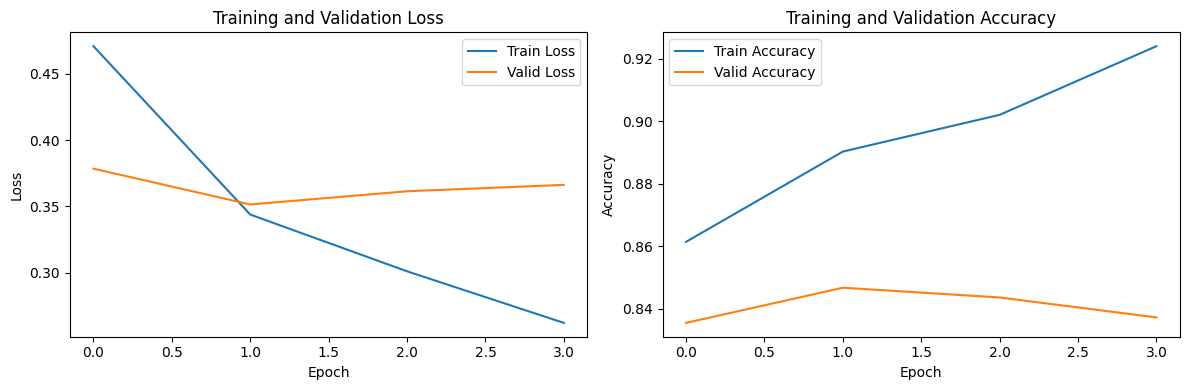

Validation Accuracy: 0.8373

Testing: lr=0.001, hidden_dim=64, n_layers=2, dropout=0.5
Epoch 1/15:
  Train Loss: 0.4947, Train Acc: 0.8508
  Valid Loss: 0.3876, Valid Acc: 0.8296
  ↳ New best validation loss: 0.3876
Epoch 2/15:
  Train Loss: 0.3550, Train Acc: 0.8861
  Valid Loss: 0.3532, Valid Acc: 0.8442
  ↳ New best validation loss: 0.3532
Epoch 3/15:
  Train Loss: 0.3127, Train Acc: 0.9025
  Valid Loss: 0.3556, Valid Acc: 0.8459
  ↳ No improvement for 1/2 epochs
Epoch 4/15:
  Train Loss: 0.2778, Train Acc: 0.9251
  Valid Loss: 0.3525, Valid Acc: 0.8462
  ↳ New best validation loss: 0.3525
Epoch 5/15:
  Train Loss: 0.2402, Train Acc: 0.9387
  Valid Loss: 0.3812, Valid Acc: 0.8434
  ↳ No improvement for 1/2 epochs
Epoch 6/15:
  Train Loss: 0.2142, Train Acc: 0.9540
  Valid Loss: 0.4105, Valid Acc: 0.8420
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 6


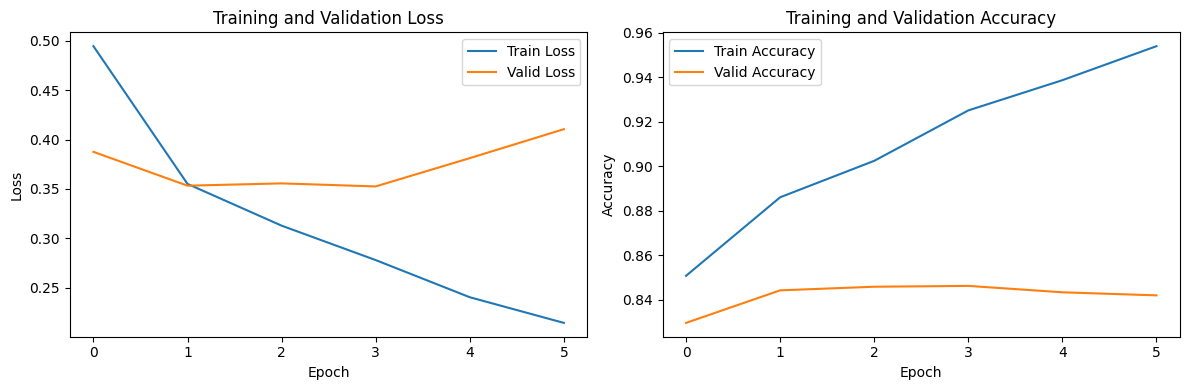

Validation Accuracy: 0.8420

Testing: lr=0.001, hidden_dim=128, n_layers=1, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4478, Train Acc: 0.8582
  Valid Loss: 0.3671, Valid Acc: 0.8389
  ↳ New best validation loss: 0.3671
Epoch 2/15:
  Train Loss: 0.3230, Train Acc: 0.8961
  Valid Loss: 0.3382, Valid Acc: 0.8535
  ↳ New best validation loss: 0.3382
Epoch 3/15:
  Train Loss: 0.2821, Train Acc: 0.9167
  Valid Loss: 0.3372, Valid Acc: 0.8520
  ↳ New best validation loss: 0.3372
Epoch 4/15:
  Train Loss: 0.2428, Train Acc: 0.9393
  Valid Loss: 0.3561, Valid Acc: 0.8508
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2005, Train Acc: 0.9553
  Valid Loss: 0.3728, Valid Acc: 0.8489
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


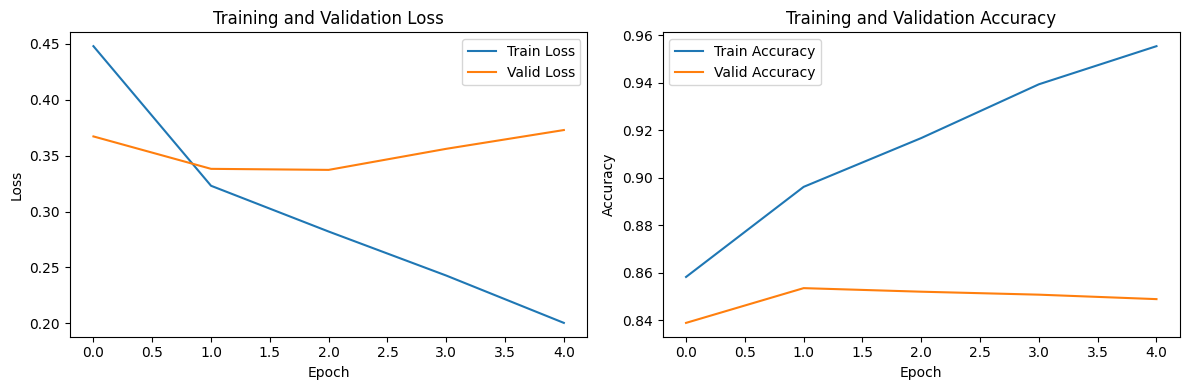

Validation Accuracy: 0.8489

Testing: lr=0.001, hidden_dim=128, n_layers=1, dropout=0.5
Epoch 1/15:
  Train Loss: 0.4934, Train Acc: 0.8638
  Valid Loss: 0.3630, Valid Acc: 0.8404
  ↳ New best validation loss: 0.3630
Epoch 2/15:
  Train Loss: 0.3521, Train Acc: 0.8825
  Valid Loss: 0.3489, Valid Acc: 0.8479
  ↳ New best validation loss: 0.3489
Epoch 3/15:
  Train Loss: 0.3137, Train Acc: 0.9038
  Valid Loss: 0.3400, Valid Acc: 0.8516
  ↳ New best validation loss: 0.3400
Epoch 4/15:
  Train Loss: 0.2802, Train Acc: 0.9156
  Valid Loss: 0.3544, Valid Acc: 0.8510
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2495, Train Acc: 0.9208
  Valid Loss: 0.3998, Valid Acc: 0.8380
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


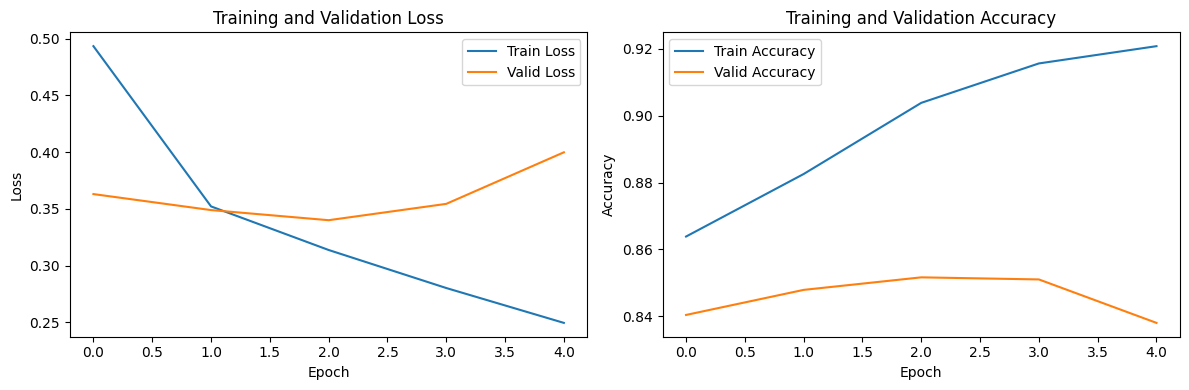

Validation Accuracy: 0.8380

Testing: lr=0.001, hidden_dim=128, n_layers=2, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4545, Train Acc: 0.8542
  Valid Loss: 0.3729, Valid Acc: 0.8345
  ↳ New best validation loss: 0.3729
Epoch 2/15:
  Train Loss: 0.3317, Train Acc: 0.8840
  Valid Loss: 0.3645, Valid Acc: 0.8413
  ↳ New best validation loss: 0.3645
Epoch 3/15:
  Train Loss: 0.2854, Train Acc: 0.9209
  Valid Loss: 0.3530, Valid Acc: 0.8460
  ↳ New best validation loss: 0.3530
Epoch 4/15:
  Train Loss: 0.2353, Train Acc: 0.9409
  Valid Loss: 0.3712, Valid Acc: 0.8400
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.1771, Train Acc: 0.9610
  Valid Loss: 0.4255, Valid Acc: 0.8400
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


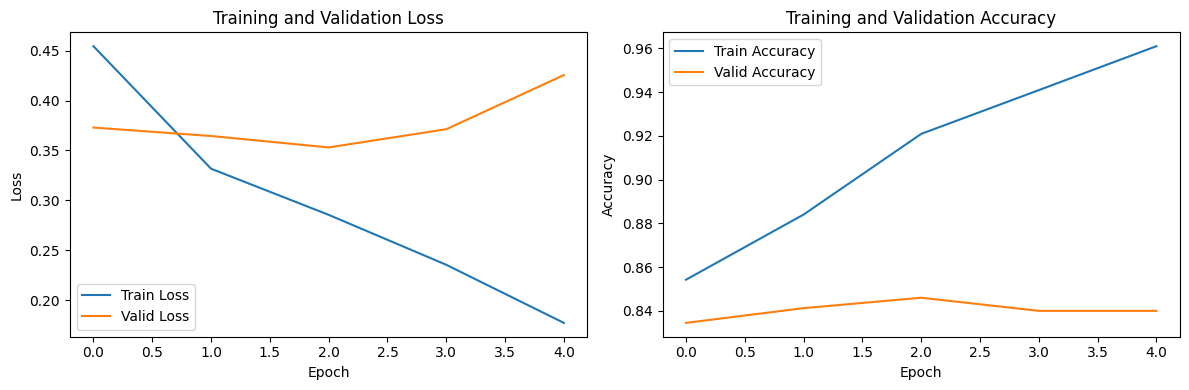

Validation Accuracy: 0.8400

Testing: lr=0.001, hidden_dim=128, n_layers=2, dropout=0.5
Epoch 1/15:
  Train Loss: 0.4819, Train Acc: 0.8579
  Valid Loss: 0.3751, Valid Acc: 0.8346
  ↳ New best validation loss: 0.3751
Epoch 2/15:
  Train Loss: 0.3493, Train Acc: 0.8831
  Valid Loss: 0.3565, Valid Acc: 0.8460
  ↳ New best validation loss: 0.3565
Epoch 3/15:
  Train Loss: 0.3061, Train Acc: 0.9069
  Valid Loss: 0.3471, Valid Acc: 0.8451
  ↳ New best validation loss: 0.3471
Epoch 4/15:
  Train Loss: 0.2640, Train Acc: 0.9287
  Valid Loss: 0.3626, Valid Acc: 0.8488
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2236, Train Acc: 0.9524
  Valid Loss: 0.3779, Valid Acc: 0.8482
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


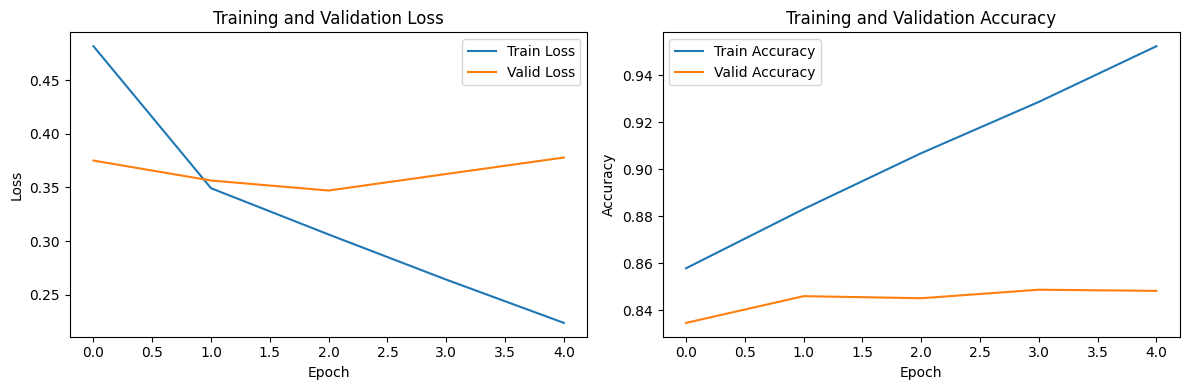

Validation Accuracy: 0.8482

Testing: lr=0.0005, hidden_dim=64, n_layers=1, dropout=0.3
Epoch 1/15:
  Train Loss: 0.5371, Train Acc: 0.8427
  Valid Loss: 0.3993, Valid Acc: 0.8271
  ↳ New best validation loss: 0.3993
Epoch 2/15:
  Train Loss: 0.3684, Train Acc: 0.8717
  Valid Loss: 0.3571, Valid Acc: 0.8406
  ↳ New best validation loss: 0.3571
Epoch 3/15:
  Train Loss: 0.3244, Train Acc: 0.8900
  Valid Loss: 0.3490, Valid Acc: 0.8474
  ↳ New best validation loss: 0.3490
Epoch 4/15:
  Train Loss: 0.2981, Train Acc: 0.9009
  Valid Loss: 0.3449, Valid Acc: 0.8475
  ↳ New best validation loss: 0.3449
Epoch 5/15:
  Train Loss: 0.2739, Train Acc: 0.9137
  Valid Loss: 0.3557, Valid Acc: 0.8464
  ↳ No improvement for 1/2 epochs
Epoch 6/15:
  Train Loss: 0.2507, Train Acc: 0.9234
  Valid Loss: 0.3495, Valid Acc: 0.8462
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 6


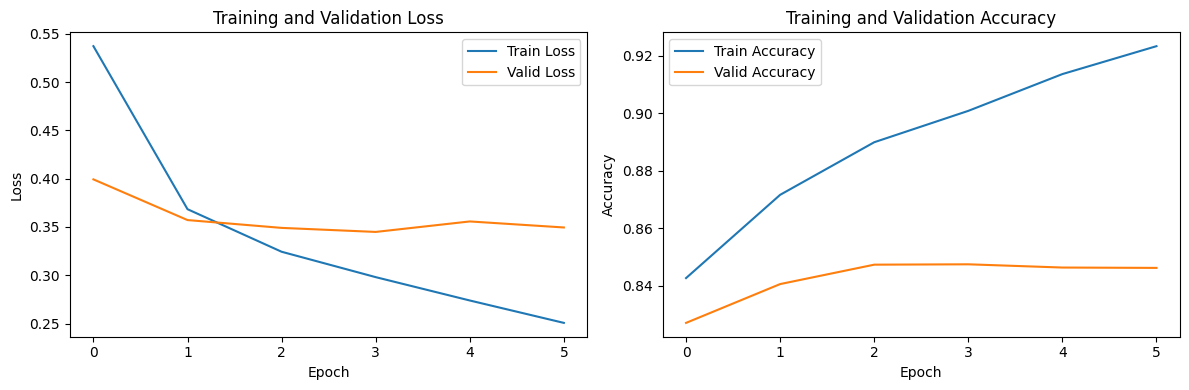

Validation Accuracy: 0.8462

Testing: lr=0.0005, hidden_dim=64, n_layers=1, dropout=0.5
Epoch 1/15:
  Train Loss: 0.5612, Train Acc: 0.8384
  Valid Loss: 0.4116, Valid Acc: 0.8224
  ↳ New best validation loss: 0.4116
Epoch 2/15:
  Train Loss: 0.3852, Train Acc: 0.8703
  Valid Loss: 0.3670, Valid Acc: 0.8387
  ↳ New best validation loss: 0.3670
Epoch 3/15:
  Train Loss: 0.3369, Train Acc: 0.8829
  Valid Loss: 0.3571, Valid Acc: 0.8419
  ↳ New best validation loss: 0.3571
Epoch 4/15:
  Train Loss: 0.3123, Train Acc: 0.8961
  Valid Loss: 0.3556, Valid Acc: 0.8470
  ↳ New best validation loss: 0.3556
Epoch 5/15:
  Train Loss: 0.2896, Train Acc: 0.9058
  Valid Loss: 0.3562, Valid Acc: 0.8472
  ↳ No improvement for 1/2 epochs
Epoch 6/15:
  Train Loss: 0.2749, Train Acc: 0.9164
  Valid Loss: 0.3719, Valid Acc: 0.8458
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 6


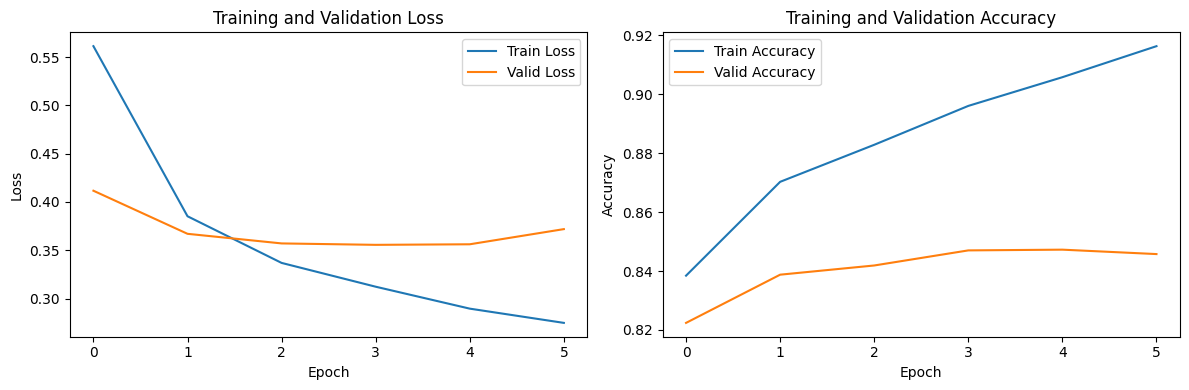

Validation Accuracy: 0.8458

Testing: lr=0.0005, hidden_dim=64, n_layers=2, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4961, Train Acc: 0.8515
  Valid Loss: 0.3889, Valid Acc: 0.8266
  ↳ New best validation loss: 0.3889
Epoch 2/15:
  Train Loss: 0.3546, Train Acc: 0.8614
  Valid Loss: 0.3869, Valid Acc: 0.8260
  ↳ New best validation loss: 0.3869
Epoch 3/15:
  Train Loss: 0.3128, Train Acc: 0.8960
  Valid Loss: 0.3564, Valid Acc: 0.8431
  ↳ New best validation loss: 0.3564
Epoch 4/15:
  Train Loss: 0.2832, Train Acc: 0.8981
  Valid Loss: 0.3886, Valid Acc: 0.8364
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2513, Train Acc: 0.9287
  Valid Loss: 0.3892, Valid Acc: 0.8435
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


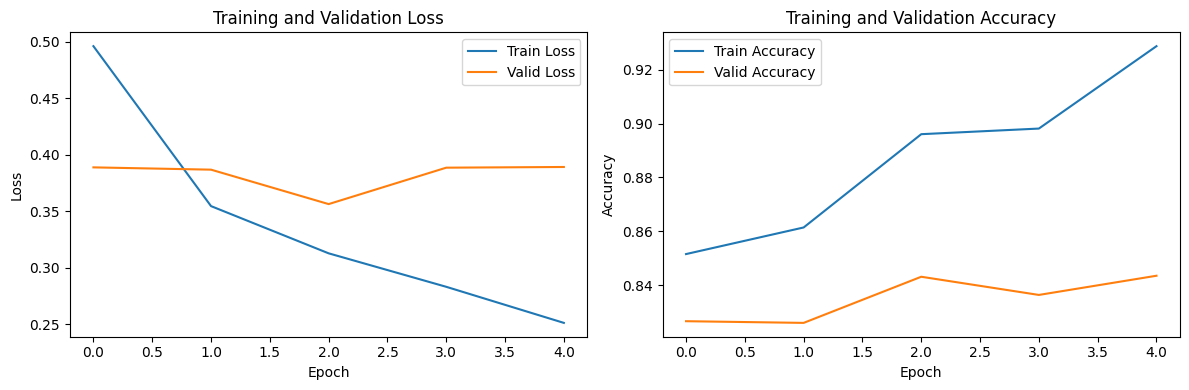

Validation Accuracy: 0.8435

Testing: lr=0.0005, hidden_dim=64, n_layers=2, dropout=0.5
Epoch 1/15:
  Train Loss: 0.5320, Train Acc: 0.8437
  Valid Loss: 0.3943, Valid Acc: 0.8254
  ↳ New best validation loss: 0.3943
Epoch 2/15:
  Train Loss: 0.3749, Train Acc: 0.8588
  Valid Loss: 0.3814, Valid Acc: 0.8329
  ↳ New best validation loss: 0.3814
Epoch 3/15:
  Train Loss: 0.3333, Train Acc: 0.8864
  Valid Loss: 0.3574, Valid Acc: 0.8469
  ↳ New best validation loss: 0.3574
Epoch 4/15:
  Train Loss: 0.3005, Train Acc: 0.9040
  Valid Loss: 0.3606, Valid Acc: 0.8441
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2737, Train Acc: 0.9185
  Valid Loss: 0.3654, Valid Acc: 0.8508
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


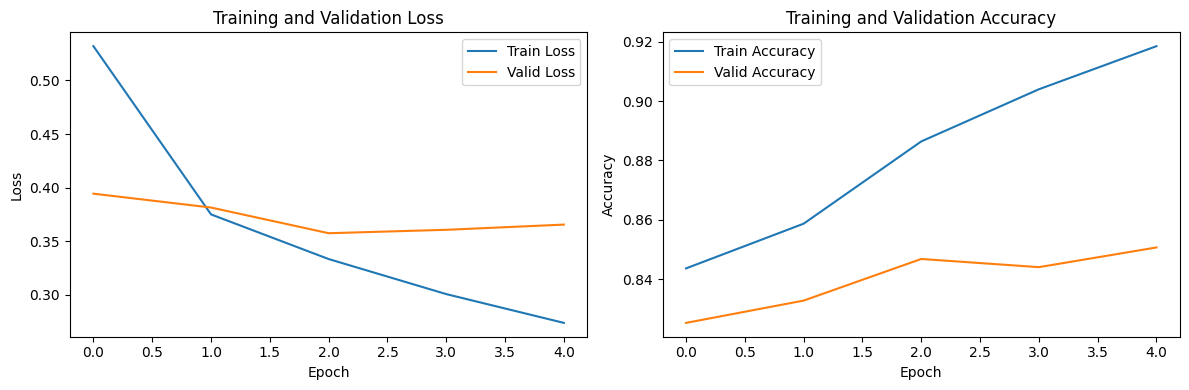

Validation Accuracy: 0.8508

Testing: lr=0.0005, hidden_dim=128, n_layers=1, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4924, Train Acc: 0.8521
  Valid Loss: 0.3777, Valid Acc: 0.8377
  ↳ New best validation loss: 0.3777
Epoch 2/15:
  Train Loss: 0.3521, Train Acc: 0.8774
  Valid Loss: 0.3503, Valid Acc: 0.8469
  ↳ New best validation loss: 0.3503
Epoch 3/15:
  Train Loss: 0.3112, Train Acc: 0.8913
  Valid Loss: 0.3471, Valid Acc: 0.8449
  ↳ New best validation loss: 0.3471
Epoch 4/15:
  Train Loss: 0.2793, Train Acc: 0.8898
  Valid Loss: 0.3739, Valid Acc: 0.8395
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2506, Train Acc: 0.9291
  Valid Loss: 0.3451, Valid Acc: 0.8491
  ↳ New best validation loss: 0.3451
Epoch 6/15:
  Train Loss: 0.2211, Train Acc: 0.9437
  Valid Loss: 0.3714, Valid Acc: 0.8490
  ↳ No improvement for 1/2 epochs
Epoch 7/15:
  Train Loss: 0.1922, Train Acc: 0.9567
  Valid Loss: 0.3738, Valid Acc: 0.8501
  ↳ No improvement for 2/2 epochs
Early stopping tr

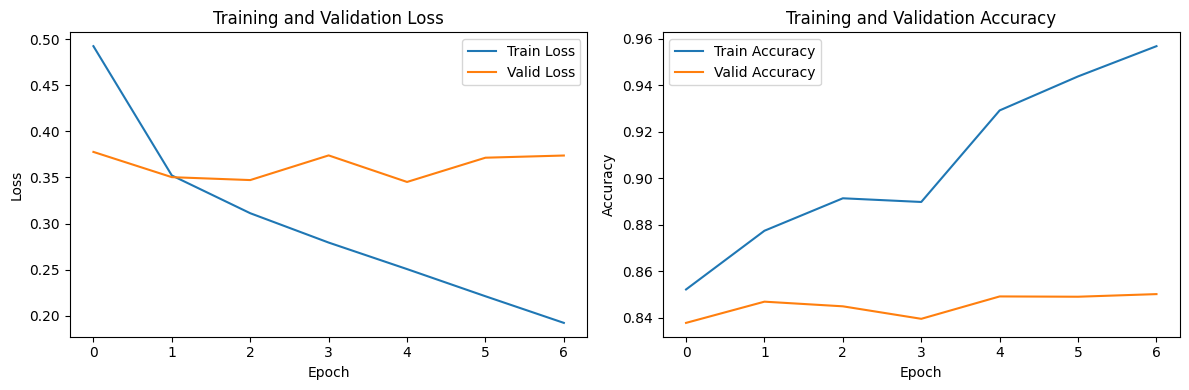

Validation Accuracy: 0.8501

Testing: lr=0.0005, hidden_dim=128, n_layers=1, dropout=0.5
Epoch 1/15:
  Train Loss: 0.4964, Train Acc: 0.8440
  Valid Loss: 0.3818, Valid Acc: 0.8251
  ↳ New best validation loss: 0.3818
Epoch 2/15:
  Train Loss: 0.3617, Train Acc: 0.8758
  Valid Loss: 0.3536, Valid Acc: 0.8449
  ↳ New best validation loss: 0.3536
Epoch 3/15:
  Train Loss: 0.3198, Train Acc: 0.8924
  Valid Loss: 0.3447, Valid Acc: 0.8492
  ↳ New best validation loss: 0.3447
Epoch 4/15:
  Train Loss: 0.2939, Train Acc: 0.8958
  Valid Loss: 0.3663, Valid Acc: 0.8438
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2709, Train Acc: 0.9132
  Valid Loss: 0.3765, Valid Acc: 0.8465
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


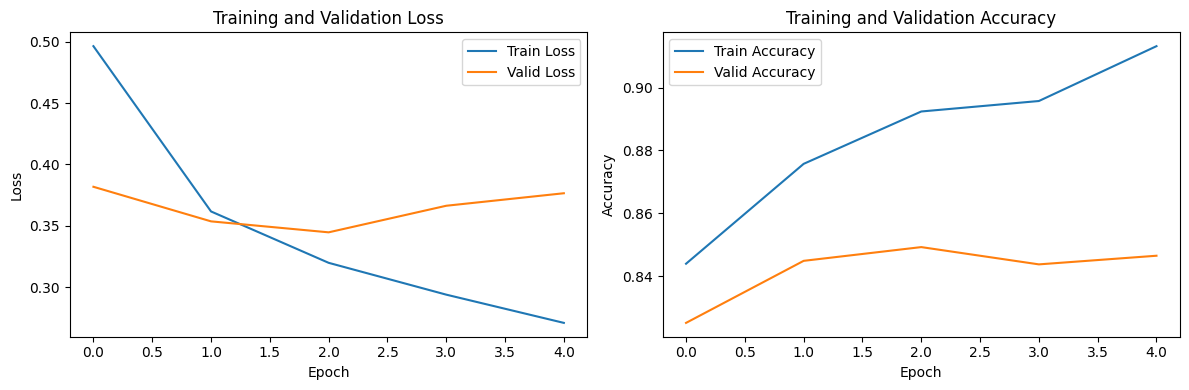

Validation Accuracy: 0.8465

Testing: lr=0.0005, hidden_dim=128, n_layers=2, dropout=0.3
Epoch 1/15:
  Train Loss: 0.4869, Train Acc: 0.8497
  Valid Loss: 0.3858, Valid Acc: 0.8251
  ↳ New best validation loss: 0.3858
Epoch 2/15:
  Train Loss: 0.3498, Train Acc: 0.8831
  Valid Loss: 0.3559, Valid Acc: 0.8405
  ↳ New best validation loss: 0.3559
Epoch 3/15:
  Train Loss: 0.3056, Train Acc: 0.9048
  Valid Loss: 0.3429, Valid Acc: 0.8496
  ↳ New best validation loss: 0.3429
Epoch 4/15:
  Train Loss: 0.2642, Train Acc: 0.9273
  Valid Loss: 0.3562, Valid Acc: 0.8433
  ↳ No improvement for 1/2 epochs
Epoch 5/15:
  Train Loss: 0.2221, Train Acc: 0.9421
  Valid Loss: 0.3859, Valid Acc: 0.8433
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 5


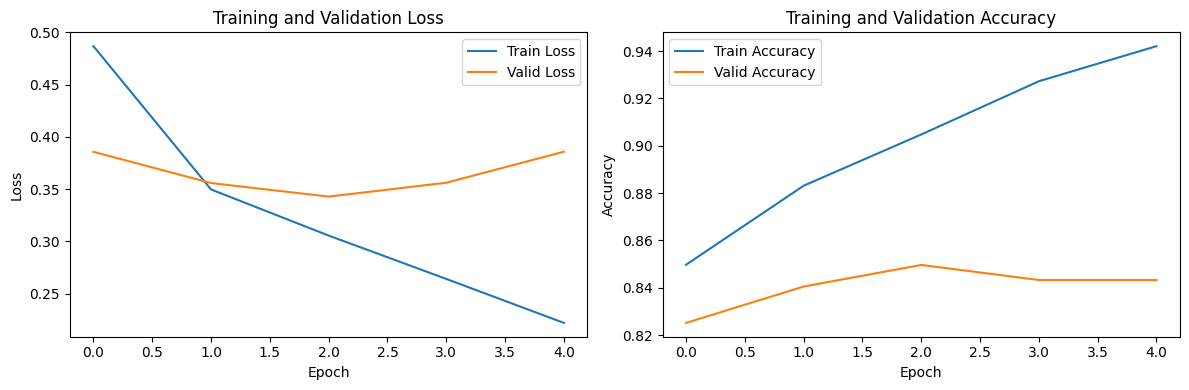

Validation Accuracy: 0.8433

Testing: lr=0.0005, hidden_dim=128, n_layers=2, dropout=0.5
Epoch 1/15:
  Train Loss: 0.5008, Train Acc: 0.8398
  Valid Loss: 0.3993, Valid Acc: 0.8197
  ↳ New best validation loss: 0.3993
Epoch 2/15:
  Train Loss: 0.3591, Train Acc: 0.8773
  Valid Loss: 0.3566, Valid Acc: 0.8442
  ↳ New best validation loss: 0.3566
Epoch 3/15:
  Train Loss: 0.3162, Train Acc: 0.8969
  Valid Loss: 0.3584, Valid Acc: 0.8448
  ↳ No improvement for 1/2 epochs
Epoch 4/15:
  Train Loss: 0.2827, Train Acc: 0.9146
  Valid Loss: 0.3479, Valid Acc: 0.8475
  ↳ New best validation loss: 0.3479
Epoch 5/15:
  Train Loss: 0.2423, Train Acc: 0.9400
  Valid Loss: 0.3800, Valid Acc: 0.8449
  ↳ No improvement for 1/2 epochs
Epoch 6/15:
  Train Loss: 0.2021, Train Acc: 0.9497
  Valid Loss: 0.4140, Valid Acc: 0.8410
  ↳ No improvement for 2/2 epochs
Early stopping triggered at epoch 6


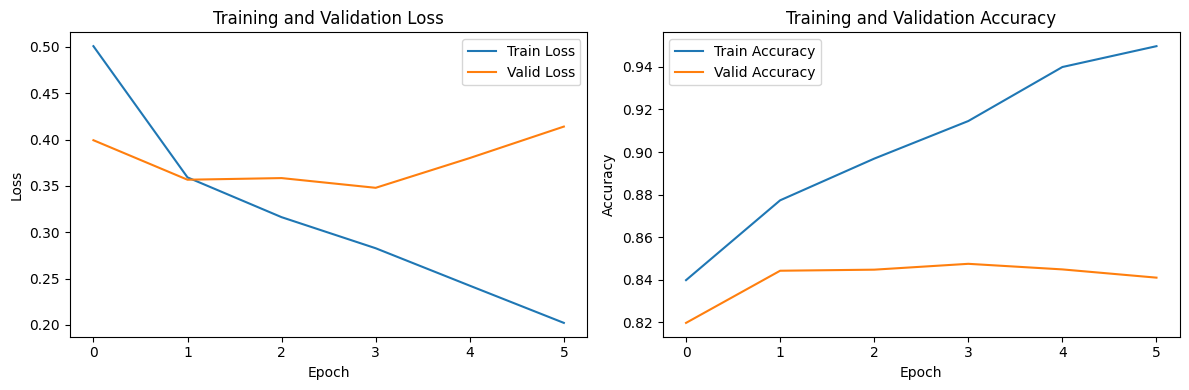

Validation Accuracy: 0.8410

=== BEST HYPERPARAMETERS ===
Best Validation Accuracy: 0.8508
Best Parameters: {'learning_rate': 0.0005, 'hidden_dim': 64, 'n_layers': 2, 'dropout': 0.5}


In [ ]:
# Hyperparameter Tuning (Practical Version)

# Reduced hyperparameter combinations
hyperparams = {
    'learning_rate': [0.001, 0.0005],
    'hidden_dim': [64, 128],
    'n_layers': [1, 2],
    'dropout': [0.3, 0.5]
}

best_accuracy = 0
best_params = {}

print("=== HYPERPARAMETER TUNING ===")
print(f"Total models to train: {2*2*2*2} = 16 models")

# Grid search over hyperparameters
for lr in hyperparams['learning_rate']:
    for hidden_dim in hyperparams['hidden_dim']:
        for n_layers in hyperparams['n_layers']:
            for dropout in hyperparams['dropout']:

                print(f"\nTesting: lr={lr}, hidden_dim={hidden_dim}, n_layers={n_layers}, dropout={dropout}")

                # Create model with current hyperparameters
                model = SentimentRNN(
                    vocab_size=1000,
                    embedding_dim=128,
                    hidden_dim=hidden_dim,
                    n_layers=n_layers,
                    dropout=dropout
                )

                # Train briefly for evaluation with early stopping
                model = train_model(model, train_loader, valid_loader, epochs=15, lr=lr, patience=2)

                # Evaluate on validation set
                val_accuracy = get_accuracy(model, valid_loader)
                print(f"Validation Accuracy: {val_accuracy:.4f}")

                # Save best model
                if val_accuracy > best_accuracy:
                    best_accuracy = val_accuracy
                    best_params = {
                        'learning_rate': lr,
                        'hidden_dim': hidden_dim,
                        'n_layers': n_layers,
                        'dropout': dropout
                    }

print(f"\n=== BEST HYPERPARAMETERS ===")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print(f"Best Parameters: {best_params}")

=== TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS ===
Epoch 1/15:
  Train Loss: 0.5382, Train Acc: 0.8457
  Valid Loss: 0.4019, Valid Acc: 0.8266
  ↳ New best validation loss: 0.4019
Epoch 2/15:
  Train Loss: 0.3776, Train Acc: 0.8715
  Valid Loss: 0.3642, Valid Acc: 0.8401
  ↳ New best validation loss: 0.3642
Epoch 3/15:
  Train Loss: 0.3335, Train Acc: 0.8922
  Valid Loss: 0.3583, Valid Acc: 0.8452
  ↳ New best validation loss: 0.3583
Epoch 4/15:
  Train Loss: 0.3043, Train Acc: 0.9011
  Valid Loss: 0.3586, Valid Acc: 0.8442
  ↳ No improvement for 1/3 epochs
Epoch 5/15:
  Train Loss: 0.2748, Train Acc: 0.9177
  Valid Loss: 0.3810, Valid Acc: 0.8415
  ↳ No improvement for 2/3 epochs
Epoch 6/15:
  Train Loss: 0.2467, Train Acc: 0.9299
  Valid Loss: 0.3885, Valid Acc: 0.8413
  ↳ No improvement for 3/3 epochs
Early stopping triggered at epoch 6


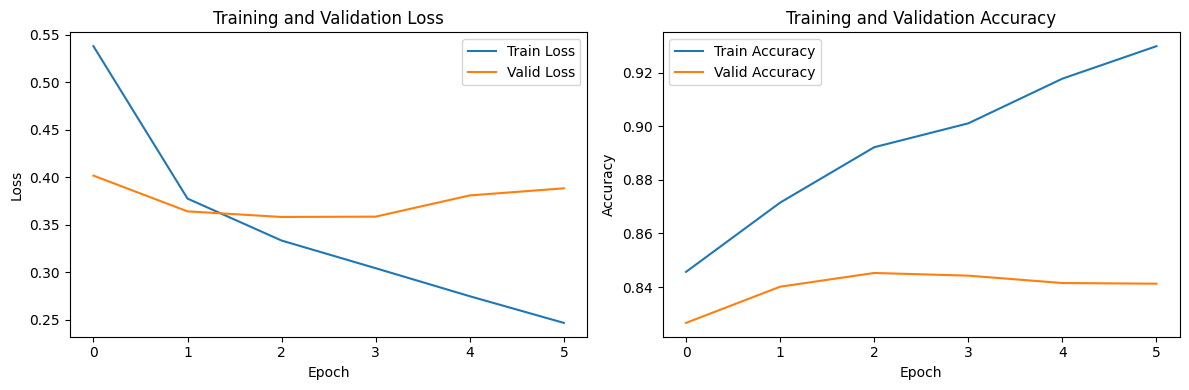

In [ ]:
print("=== TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS ===")
final_model = SentimentRNN(
    vocab_size=1000,
    embedding_dim=128,
    hidden_dim=64,  # best_params['hidden_dim']
    n_layers=2,      # best_params['n_layers']
    dropout=0.5      # best_params['dropout']
)

# Train for 15 epochs with best learning rate
final_model = train_model(final_model, train_loader, valid_loader,
                         epochs=15, lr=0.0005)  # best_params['learning_rate']

In [ ]:
# Final evaluation on all datasets
X_test_tensor = torch.tensor(X_test_padded)
y_test_tensor = torch.tensor(y_test_encoded)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
print("\n=== FINAL ACCURACIES ===")
train_accuracy = get_accuracy(final_model, train_loader)
valid_accuracy = get_accuracy(final_model, valid_loader)
test_accuracy = get_accuracy(final_model, test_loader)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {valid_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


=== FINAL ACCURACIES ===
Training Accuracy: 0.9299
Validation Accuracy: 0.8413
Test Accuracy: 0.8364


In [ ]:


def analyze_errors(model, test_loader, X_test_original, y_test_original):
    model.eval()
    false_positives = []  # Actual negative, predicted positive
    false_negatives = []  # Actual positive, predicted negative

    with torch.no_grad():
        for i, (batch_x, batch_y) in enumerate(test_loader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs, _ = model(batch_x)
            predictions = torch.round(torch.sigmoid(outputs)).squeeze()

            # Get batch indices in the original dataset
            start_idx = i * test_loader.batch_size
            end_idx = start_idx + len(batch_y)
            batch_original_reviews = X_test_original[start_idx:end_idx]
            batch_original_labels = y_test_original[start_idx:end_idx]

            for j in range(len(batch_y)):
                actual = batch_y[j].item()
                predicted = predictions[j].item()
                review_text = batch_original_reviews[j]
                original_sentiment = batch_original_labels[j]

                if actual == 0 and predicted == 1:  # False Positive
                    false_positives.append(review_text)
                elif actual == 1 and predicted == 0:  # False Negative
                    false_negatives.append(review_text)

                # Stop when we have enough examples
                if len(false_positives) >= 3 and len(false_negatives) >= 3:
                    break
            if len(false_positives) >= 3 and len(false_negatives) >= 3:
                break

    return false_positives[:3], false_negatives[:3]

# Get error examples
false_positives, false_negatives = analyze_errors(final_model, test_loader, X_test, y_test)




In [ ]:
print("FALSE POSITIVES (Negative reviews predicted as Positive)")

for i, review in enumerate(false_positives, 1):
    print(f"\n--- False Positive Example {i} ---")
    print(review)
    print("-" * 50)

FALSE POSITIVES (Negative reviews predicted as Positive)

--- False Positive Example 1 ---
This movie was a great disappointment for me. I had been waiting for this movie to come out for years, and I was a faithful follower of Chaos Comics until they went bankrupt. Not only did they cut out half the story line, but they altered information. The statement that Lucifer is Hope's Father is untrue. He did corrupt her father, but he himself is not her father. The voices also did not suit the characters, and once you hear the voice of a beloved character, the voice you heard in your mind can never be returned. I can not even remember everything about this film that was wrong. The bottom line is if you love Lady Death do not watch this movie. It just did not do the comic justice at all!!
--------------------------------------------------

--- False Positive Example 2 ---
What the (beep) is going wrong with Disney the last years? Are there totally run out of good ideas? Where is the magic? Whe

In [ ]:
print("FALSE NEGATIVES (Positive reviews predicted as Negative)")

for i, review in enumerate(false_negatives, 1):
    print(f"\n--- False Negative Example {i} ---")
    print(review)
    print("-" * 50)

FALSE NEGATIVES (Positive reviews predicted as Negative)

--- False Negative Example 1 ---
I too saw this film at a film festival, but unlike the previous poster I found it both interesting and original. In a sea of terrible features, shorts are often twice as bad do to small budgets and poor acting, A.W.O.L however is a taut little thriller that hearkens back to "The Outer Limits." The performances are solid, not that one would expect otherwise from Morse or McGinley, and the directing is sharp and on the money. I personally find it difficult to reconcile the previous poster's comments with the film I saw. A.W.O.L is quite aptly written by Shane Black, who, as is usually the case, plays with the genre both paying homage to the stories pulp sensibilities, while simultaneously winking at the audience and never taking itself too seriously. All in all A.W.O.L proves to be an extremely well executed and fun film.
--------------------------------------------------

--- False Negative Exampl

In [ ]:




#  - Predict probability for given review

def predict_review_sentiment(model, review_text, stoi, seq_len=500):
    # Preprocess the review using the same functions
    processed_words = preprocess_sentence(review_text)

    # Convert words to tokens using the same vocabulary
    tokens = [stoi[word] for word in processed_words if word in stoi.keys()]

    # Pad the sequence
    padded_tokens = np.zeros(seq_len, dtype=int)
    if len(tokens) > 0:
        padded_tokens[-len(tokens):] = tokens[:seq_len]

    # Convert to tensor and predict
    input_tensor = torch.tensor(padded_tokens).unsqueeze(0).to(device)  # Add batch dimension

    model.eval()
    with torch.no_grad():
        output, _ = model(input_tensor)
        probability = torch.sigmoid(output).item()

    return probability

# Process and predict the given review
review = """ Man.... I wish I loved this movie more than I did. Don't get me wrong,
it's a solid action movie with jaw-dropping stunts (some of the best in the series),
but as a Mission: Impossible movie, it felt like a small step backward for the franchise.
Fallout had mind-blowing action sequences and stunt work, along with developing Ethan's
relationship with Ilsa, providing closure with Julia, showing the lengths Ethan would
go to protect those closest to him, and battling an imposing villain. Dead Reckoning:
Part One stretches the movie across two films only to seemingly showcase action
spectacle after action spectacle while sacrificing character development.
Characters I have grown to love over a decade of films felt sidelined, ignored,
or wasted. Hayley Atwell's new character chewed up most of the screen time, and
while she was fantastic, I wanted to see more of the original team. The new villain
had an inconsistent ability that confused more than intimidated. There were some
important emotional moments that I just didn't feel the weight of when I definitely
should have. Part Two might tie everything together and make me enjoy Part One
more in retrospect, but unfortunately, I left wanting more from this one. """


probability = predict_review_sentiment(final_model, review, stoi)
sentiment = "POSITIVE" if probability > 0.5 else "NEGATIVE"


print(f"Predicted Probability of Positive Sentiment: {probability:.4f}")
print(f"Predicted Sentiment: {sentiment}")
print(f"Confidence: {probability:.1%}")



Predicted Probability of Positive Sentiment: 0.7328
Predicted Sentiment: POSITIVE
Confidence: 73.3%


#  BERT Transfer Learning


In [ ]:
# install relevant libraries
!pip install -qq transformers

In [ ]:
# load relevant libraries
import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW

PRE_TRAINED_MODEL_NAME = 'bert-base-cased'

tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

################### SUBMISSION NOTE ####################################
#  - output of this cell creates issues for converting ipynb to HTML
#  - you may want to delete this output when you are ready to submit

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [ ]:
sample_txt = 'I want to learn how to do sentiment analysis using BERT and tokenizer.'

encoding = tokenizer.encode_plus(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Add '[CLS]' and '[SEP]'
  return_token_type_ids=False,
  pad_to_max_length=True,
  return_attention_mask=True,
  return_tensors='pt',  # Return PyTorch tensors
  truncation = True
)

Keyword arguments {'pad_to_max_length': True} not recognized.


In [ ]:
encoding['input_ids']

tensor([[  101,   146,  1328,  1106,  3858,  1293,  1106,  1202, 17024,  3622,
          1606,   139,  9637,  1942,  1105, 22559, 17260,   119,   102]])

In [ ]:
encoding['attention_mask']

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

In [ ]:
hidden_states = bert_model(input_ids=encoding['input_ids'],
                           attention_mask=encoding['attention_mask'])[0]
pooled_output = bert_model(input_ids=encoding['input_ids'],
                           attention_mask=encoding['attention_mask'])[1]

In [ ]:
hidden_size = bert_model.config.hidden_size

print(hidden_size)
print(hidden_states.shape)
print(pooled_output.shape)


768
torch.Size([1, 19, 768])
torch.Size([1, 768])


In [ ]:
# Reload the IMDB dataset for Part B
df = pd.read_csv("IMDB Dataset.csv")

# Split the data for Part B (independent from Part A)
from sklearn.model_selection import train_test_split

# Split into train+valid and test (60-20-20)
df_temp, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_valid = train_test_split(df_temp, test_size=0.25, random_state=42)

print(f"Training set: {len(df_train)} samples")
print(f"Validation set: {len(df_valid)} samples")
print(f"Test set: {len(df_test)} samples")

Training set: 24000 samples
Validation set: 8000 samples
Test set: 8000 samples


In [ ]:
from torch.utils.data import Dataset, DataLoader

class MovieReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    #obtain numerical labels
    target = 1 if self.targets[item] == 'positive' else 0

    encoding = self.tokenizer.encode_plus(
      review,
      add_special_tokens=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      padding='max_length',
      return_attention_mask=True,
      return_tensors='pt',
      truncation = True
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }

In [ ]:
# Prepare data loaders
MAX_LEN = 400
BATCH_SIZE = 16

# Training data
train_data = MovieReviewDataset(
    reviews=df_train['review'].to_numpy(),
    targets=df_train['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

train_data_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)#modify num_works as needed

# Validation data
valid_data = MovieReviewDataset(
    reviews=df_valid['review'].to_numpy(),
    targets=df_valid['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

valid_data_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Test data
test_data = MovieReviewDataset(
    reviews=df_test['review'].to_numpy(),
    targets=df_test['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_data_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders created successfully!")
print(f"Training batches: {len(train_data_loader)}")
print(f"Validation batches: {len(valid_data_loader)}")
print(f"Test batches: {len(test_data_loader)}")

# Test the DataLoader with one batch
sample_batch = next(iter(train_data_loader))
print(f"\nSample batch keys: {sample_batch.keys()}")
print(f"Input IDs shape: {sample_batch['input_ids'].shape}")
print(f"Attention mask shape: {sample_batch['attention_mask'].shape}")
print(f"Targets shape: {sample_batch['targets'].shape}")

DataLoaders created successfully!
Training batches: 1500
Validation batches: 500
Test batches: 500

Sample batch keys: dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])
Input IDs shape: torch.Size([16, 400])
Attention mask shape: torch.Size([16, 400])
Targets shape: torch.Size([16])


In [ ]:




# Load one sample from the train_data_loader
sample_batch = next(iter(train_data_loader))

print("=== SAMPLE BATCH ATTRIBUTES ===")
print(f"Number of attributes: {len(sample_batch)}")
print(f"Attribute names: {list(sample_batch.keys())}")

print("\n" + "="*50)
print("DETAILED ATTRIBUTE ANALYSIS:")
print("="*50)

# Analyze each attribute
print(f"\n1. 'review_text'")
print(f"   Shape: {len(sample_batch['review_text'])} samples")
print(f"   First review preview: {sample_batch['review_text'][0][:100]}...")

print(f"\n2. 'input_ids'")
print(f"   Shape: {sample_batch['input_ids'].shape}")
print(f"   First sample tokens: {sample_batch['input_ids'][0][:20]}...")

print(f"\n3. 'attention_mask'")
print(f"   Shape: {sample_batch['attention_mask'].shape}")
print(f"   First sample mask: {sample_batch['attention_mask'][0][:20]}...")

print(f"\n4. 'targets'")
print(f"   Shape: {sample_batch['targets'].shape}")
print(f"   First few labels: {sample_batch['targets'][:10]}")


=== SAMPLE BATCH ATTRIBUTES ===
Number of attributes: 4
Attribute names: ['review_text', 'input_ids', 'attention_mask', 'targets']

DETAILED ATTRIBUTE ANALYSIS:

1. 'review_text'
   Shape: 16 samples
   First review preview: This movie was OK, as far as movies go. It could have been made as a crossover into secular movies. ...

2. 'input_ids'
   Shape: torch.Size([16, 400])
   First sample tokens: tensor([  101,  1188,  2523,  1108, 10899,   117,  1112,  1677,  1112,  5558,
         1301,   119,  1135,  1180,  1138,  1151,  1189,  1112,   170, 18847])...

3. 'attention_mask'
   Shape: torch.Size([16, 400])
   First sample mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])...

4. 'targets'
   Shape: torch.Size([16])
   First few labels: tensor([0, 1, 1, 1, 0, 1, 1, 1, 1, 0])


In [ ]:


# Get a batch of data
sample_batch = next(iter(train_data_loader))
input_ids = sample_batch['input_ids']

print("=== TOKEN VALUE ANALYSIS ===")

# Analyze token values
print(f"Token value range: [{input_ids.min().item()}, {input_ids.max().item()}]")
print(f"Unique tokens in this batch: {len(torch.unique(input_ids))}")

# Check for special tokens
special_tokens = {
    101: "[CLS]",
    102: "[SEP]",
    0: "[PAD]",
    103: "[MASK]",
    999: "[UNK]"
}

print(f"\n=== SPECIAL TOKENS FOUND ===")
for token_id, token_name in special_tokens.items():
    if (input_ids == token_id).any():
        print(f"Token {token_id}: {token_name}")

# Check distribution of token values
print(f"\n=== TOKEN VALUE DISTRIBUTION ===")
print(f"Most frequent token: {torch.mode(input_ids.flatten()).values.item()} ([PAD] tokens)")
print(f"Percentage of [PAD] tokens: {(input_ids == 0).float().mean().item()*100:.1f}%")

# Sample token decoding
print(f"\n=== TOKEN DECODING EXAMPLE ===")
sample_tokens = input_ids[0][:15]  # First 15 tokens of first sample
print(f"Token IDs: {sample_tokens.tolist()}")
print(f"Decoded text: {tokenizer.decode(sample_tokens)}")



=== TOKEN VALUE ANALYSIS ===
Token value range: [0, 27990]
Unique tokens in this batch: 1491

=== SPECIAL TOKENS FOUND ===
Token 101: [CLS]
Token 102: [SEP]
Token 0: [PAD]

=== TOKEN VALUE DISTRIBUTION ===
Most frequent token: 0 ([PAD] tokens)
Percentage of [PAD] tokens: 31.8%

=== TOKEN DECODING EXAMPLE ===
Token IDs: [101, 6355, 1330, 2793, 3789, 1115, 2196, 1115, 4613, 1169, 112, 189, 1256, 1202, 1103]
Decoded text: [CLS] Yet another recent comedy that shows that Hollywood can't even do the


TOKEN FREQUENCY ANALYSIS ACROSS DATASETS

=== TRAINING DATA TOKEN FREQUENCY ANALYSIS ===
Top 5 most frequent tokens:
1. Token     0:      [PAD] - 3,408,989 times (35.5%)
2. Token   119:          . -  255,607 times (2.7%)
3. Token  1103:        the -  221,498 times (2.3%)
4. Token   117:          , -  208,523 times (2.2%)
5. Token   170:          a -  123,789 times (1.3%)


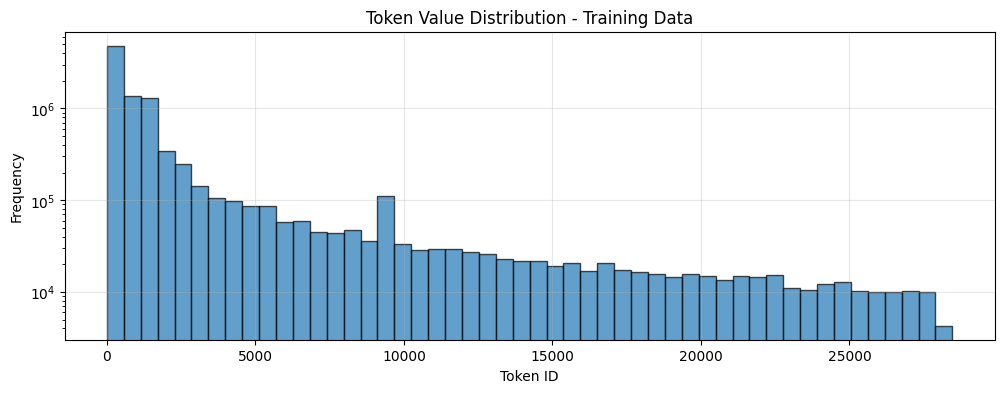


=== VALIDATION DATA TOKEN FREQUENCY ANALYSIS ===
Top 5 most frequent tokens:
1. Token     0:      [PAD] - 1,142,988 times (35.7%)
2. Token   119:          . -   85,091 times (2.7%)
3. Token  1103:        the -   73,896 times (2.3%)
4. Token   117:          , -   69,449 times (2.2%)
5. Token   170:          a -   40,932 times (1.3%)


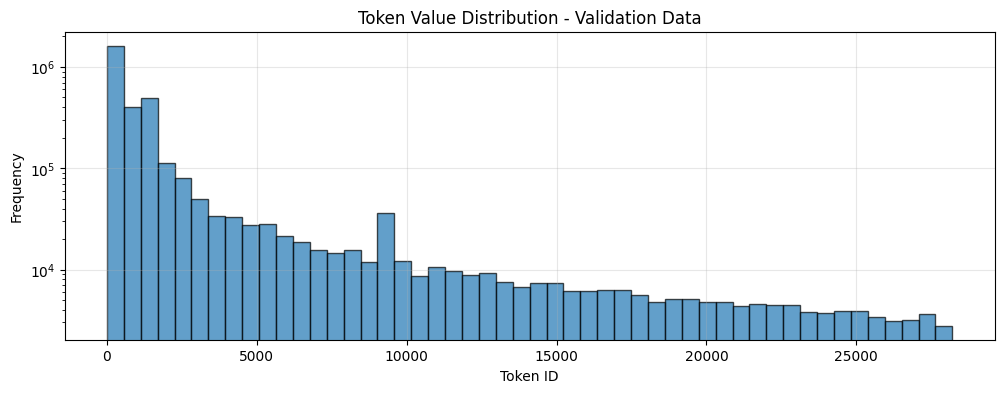


=== TEST DATA TOKEN FREQUENCY ANALYSIS ===
Top 5 most frequent tokens:
1. Token     0:      [PAD] - 1,146,837 times (35.8%)
2. Token   119:          . -   84,635 times (2.6%)
3. Token  1103:        the -   73,916 times (2.3%)
4. Token   117:          , -   69,085 times (2.2%)
5. Token   170:          a -   40,879 times (1.3%)


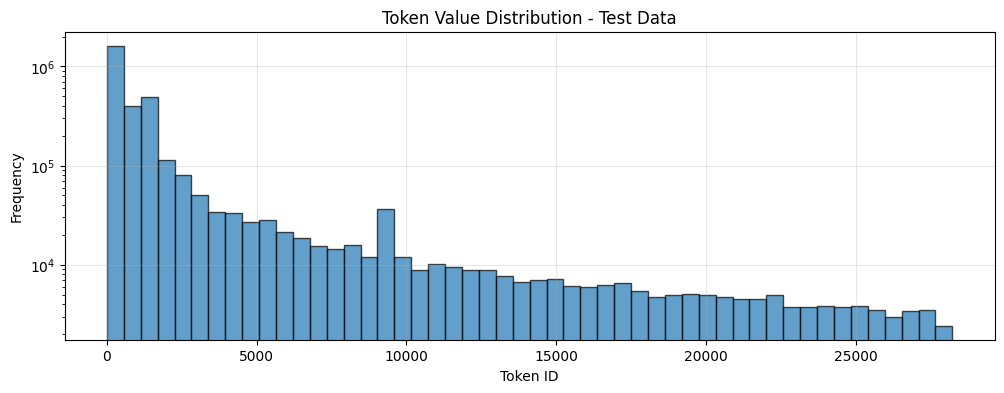

In [ ]:




def analyze_token_frequencies(data_loader, dataset_name):
    print(f"\n=== {dataset_name.upper()} TOKEN FREQUENCY ANALYSIS ===")

    # Collect all tokens
    all_tokens = []
    for batch in data_loader:
        all_tokens.append(batch['input_ids'].flatten())

    all_tokens = torch.cat(all_tokens)

    # Calculate frequencies
    unique_tokens, counts = torch.unique(all_tokens, return_counts=True)

    # Get top 5 most frequent tokens
    top_counts, top_indices = torch.topk(counts, 5)
    top_tokens = unique_tokens[top_indices]

    print("Top 5 most frequent tokens:")
    for i, (token, count) in enumerate(zip(top_tokens, top_counts)):
        percentage = (count / len(all_tokens)) * 100
        # Decode the token if possible
        try:
            decoded = tokenizer.decode([token.item()])
        except:
            decoded = "Unknown"
        print(f"{i+1}. Token {token.item():>5}: {decoded:>10} - {count.item():>8,} times ({percentage:.1f}%)")

    # Plot histogram
    plt.figure(figsize=(12, 4))
    plt.hist(all_tokens.numpy(), bins=50, alpha=0.7, edgecolor='black')
    plt.xlabel('Token ID')
    plt.ylabel('Frequency')
    plt.title(f'Token Value Distribution - {dataset_name}')
    plt.yscale('log')  # Log scale to see distribution better
    plt.grid(True, alpha=0.3)
    plt.show()

    return all_tokens

# Analyze all datasets
print("TOKEN FREQUENCY ANALYSIS ACROSS DATASETS")
print("="*50)

train_tokens = analyze_token_frequencies(train_data_loader, "Training Data")
valid_tokens = analyze_token_frequencies(valid_data_loader, "Validation Data")
test_tokens = analyze_token_frequencies(test_data_loader, "Test Data")


In [ ]:



# Get a single sample from training DataLoader
sample_batch = next(iter(train_data_loader))
single_sample = {
    'input_ids': sample_batch['input_ids'][0:1],  # First sample, keep batch dimension
    'attention_mask': sample_batch['attention_mask'][0:1]
}

print("=== SINGLE SAMPLE ANALYSIS ===")
print(f"Input IDs shape: {single_sample['input_ids'].shape}")
print(f"Attention Mask shape: {single_sample['attention_mask'].shape}")

# Feed through BERT model
bert_model.eval()
with torch.no_grad():
    outputs = bert_model(
        input_ids=single_sample['input_ids'],
        attention_mask=single_sample['attention_mask']
    )

hidden_states = outputs.last_hidden_state
pooled_output = outputs.pooler_output

print(f"\n=== BERT MODEL OUTPUTS ===")
print(f"Hidden states shape: {hidden_states.shape}")
print(f"Pooled output shape: {pooled_output.shape}")



=== SINGLE SAMPLE ANALYSIS ===
Input IDs shape: torch.Size([1, 400])
Attention Mask shape: torch.Size([1, 400])

=== BERT MODEL OUTPUTS ===
Hidden states shape: torch.Size([1, 400, 768])
Pooled output shape: torch.Size([1, 768])


In [ ]:
class SentimentClassifierPooled(nn.Module):
    def __init__(self, n_classes):
        super(SentimentClassifierPooled, self).__init__()
        self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        pooled_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[1]
        # Apply dropout for regularization
        output = self.dropout(pooled_output)
        # Return the final classification output
        return self.classifier(output)



In [ ]:
class SentimentClassifierLast(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifierLast, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.dropout = nn.Dropout(0.3)
    self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    # TO BE COMPLETED

  def forward(self, input_ids, attention_mask):

    # TO BE COMPLETED
        # Get last hidden states from BERT (shape: [batch_size, seq_len, hidden_size])
        last_hidden_state = self.bert(input_ids=input_ids, attention_mask=attention_mask)[0]
        # Use the [CLS] token embedding (first token) as summary
        cls_embedding = last_hidden_state[:, 0, :]
        output = self.drop(cls_embedding)
        return self.out(output)

In [ ]:
def get_accuracy(model, data_loader):
    """ Compute the accuracy of the `model` across a dataset `data`

    Example usage:

    >>> model = MyRNN() # to be defined
    >>> get_accuracy(model, valid_loader) # the variable `valid_loader` is from above
    """

    # TO BE COMPLETED
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            # Get model predictions
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # Get predicted class (0 or 1)
            _, predicted = torch.max(outputs, 1)

            # Count correct predictions
            correct += (predicted == targets).sum().item()
            total += targets.size(0)

    accuracy = correct / total
    return accuracy



In [ ]:

def train_model(model, train_loader, valid_loader, epochs=3, lr=2e-5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr)

    # Learning rate scheduler
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')
        print('-' * 50)

        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, targets)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == targets).sum().item()
            train_total += targets.size(0)

        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # Validation phase
        model.eval()
        valid_loss = 0
        valid_correct = 0
        valid_total = 0

        with torch.no_grad():
            for batch in valid_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                targets = batch['targets'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, targets)

                valid_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                valid_correct += (predicted == targets).sum().item()
                valid_total += targets.size(0)

        avg_valid_loss = valid_loss / len(valid_loader)
        valid_accuracy = valid_correct / valid_total

        # Store metrics
        train_losses.append(avg_train_loss)
        valid_losses.append(avg_valid_loss)
        train_accs.append(train_accuracy)
        valid_accs.append(valid_accuracy)

        print(f'Training Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.4f}')
        print(f'Validation Loss: {avg_valid_loss:.4f}, Accuracy: {valid_accuracy:.4f}')

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(valid_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(valid_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    plt.tight_layout()
    plt.show()

    return model


=== TESTING ONE HYPERPARAMETER COMBINATION ===
Testing: lr=2e-05, batch_size=8, max_len=256, dropout=0.3

Epoch 1/1
--------------------------------------------------
Training Loss: 0.3202, Accuracy: 0.8854
Validation Loss: 0.2632, Accuracy: 0.9164


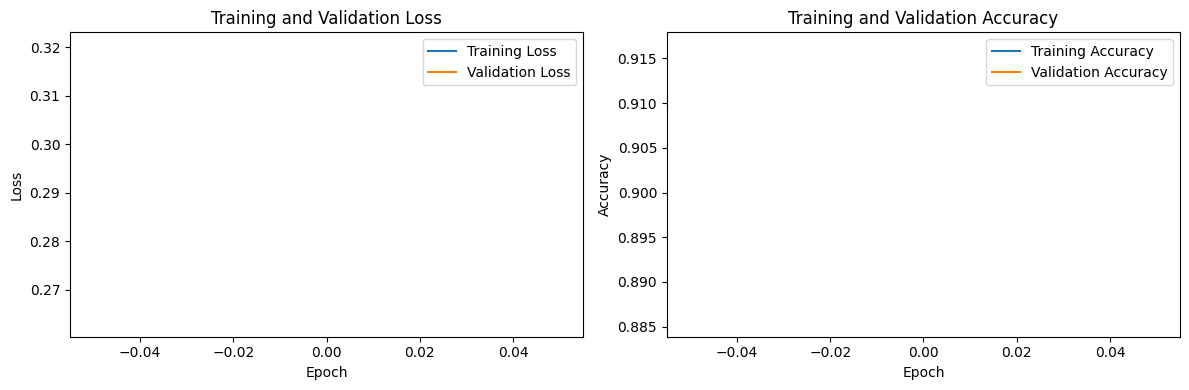

Validation Accuracy: 0.9164


In [ ]:
#  Test one hyperparameter combination

print("=== TESTING ONE HYPERPARAMETER COMBINATION ===")

# Test one combination
lr = 2e-5
batch_size = 8     # was 16 → cut in half
max_len = 256      # was 400 → reduce sequence length
dropout = 0.3

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

# Create DataLoaders with current parameters
train_data = MovieReviewDataset(
    reviews=df_train['review'].to_numpy(),
    targets=df_train['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

valid_data = MovieReviewDataset(
    reviews=df_valid['review'].to_numpy(),
    targets=df_valid['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

# Create model with current dropout
model = SentimentClassifierPooled(n_classes=2)
model.dropout = nn.Dropout(dropout)

# Train briefly for evaluation
model = train_model(model, train_loader, valid_loader, epochs=1, lr=lr)

# Evaluate on validation set
val_accuracy = get_accuracy(model, valid_loader)
print(f"Validation Accuracy: {val_accuracy:.4f}")

=== MODEL 1: BASELINE ===
Testing: lr=2e-05, batch_size=16, max_len=400, dropout=0.3
Training Model 1...

Epoch 1/3
--------------------------------------------------
Training Loss: 0.2650, Accuracy: 0.8988
Validation Loss: 0.2058, Accuracy: 0.9207

Epoch 2/3
--------------------------------------------------
Training Loss: 0.1388, Accuracy: 0.9588
Validation Loss: 0.2431, Accuracy: 0.9346

Epoch 3/3
--------------------------------------------------
Training Loss: 0.0678, Accuracy: 0.9834
Validation Loss: 0.3037, Accuracy: 0.9356


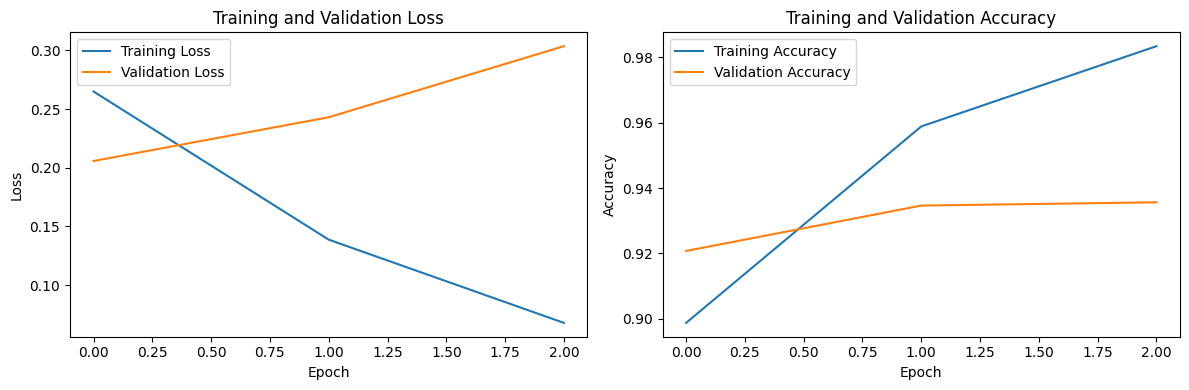

Model 1 Final Validation Accuracy: 0.9356


In [ ]:

# Model 1: Baseline BERT parameters
print("=== MODEL 1: BASELINE ===")

lr = 2e-5
batch_size = 16
max_len = 400
dropout = 0.3

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

# Create DataLoaders
train_data = MovieReviewDataset(
    reviews=df_train['review'].to_numpy(),
    targets=df_train['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

valid_data = MovieReviewDataset(
    reviews=df_valid['review'].to_numpy(),
    targets=df_valid['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

# Create and train model
model1 = SentimentClassifierPooled(n_classes=2)
model1.dropout = nn.Dropout(dropout)

print("Training Model 1...")
model1 = train_model(model1, train_loader, valid_loader, epochs=3, lr=lr)

# Final evaluation
final_acc1 = get_accuracy(model1, valid_loader)
print(f"Model 1 Final Validation Accuracy: {final_acc1:.4f}")

torch.save(model1.state_dict(), 'model1_sentiment_model.pth')

=== MODEL 2: HIGHER LEARNING RATE ===
Testing: lr=5e-05, batch_size=16, max_len=400, dropout=0.3
Training Model 2...

Epoch 1/3
--------------------------------------------------
Training Loss: 0.3020, Accuracy: 0.8798
Validation Loss: 0.2139, Accuracy: 0.9139

Epoch 2/3
--------------------------------------------------
Training Loss: 0.1559, Accuracy: 0.9533
Validation Loss: 0.2778, Accuracy: 0.9294

Epoch 3/3
--------------------------------------------------
Training Loss: 0.0619, Accuracy: 0.9860
Validation Loss: 0.3350, Accuracy: 0.9341


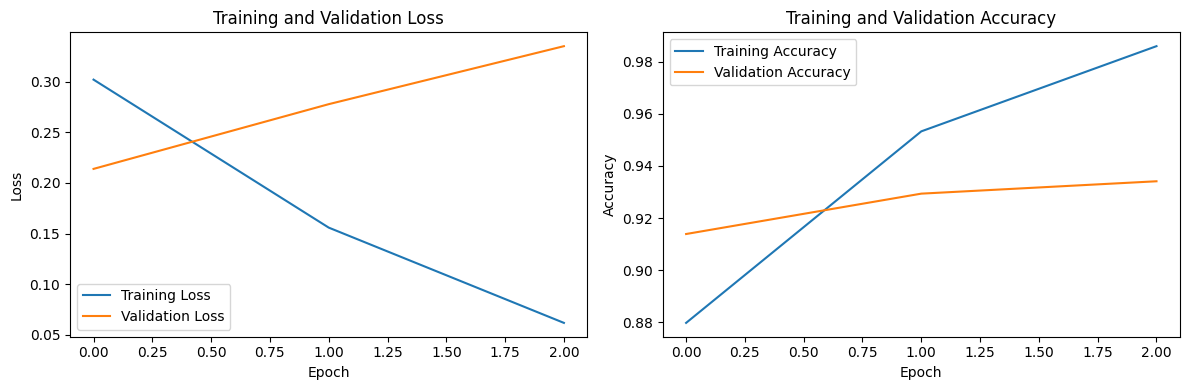

Model 2 Final Validation Accuracy: 0.9341


In [ ]:
# Model 2: Different learning rate
print("=== MODEL 2: HIGHER LEARNING RATE ===")

lr = 5e-5  # Different from Model 1 (was 2e-5)
batch_size = 16
max_len = 400
dropout = 0.3

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

# Create DataLoaders (same as Model 1)
train_data = MovieReviewDataset(
    reviews=df_train['review'].to_numpy(),
    targets=df_train['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

valid_data = MovieReviewDataset(
    reviews=df_valid['review'].to_numpy(),
    targets=df_valid['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

# Create and train model
model2 = SentimentClassifierPooled(n_classes=2)
model2.dropout = nn.Dropout(dropout)

print("Training Model 2...")
model2 = train_model(model2, train_loader, valid_loader, epochs=3, lr=lr)  # 1 epoch for speed

# Final evaluation
final_acc2 = get_accuracy(model2, valid_loader)
print(f"Model 2 Final Validation Accuracy: {final_acc2:.4f}")
torch.save(model2.state_dict(), 'model2_sentiment_model.pth')

In [ ]:
# Model 3: Larger batch size
print("\n" + "="*50)
print("MODEL 3: LARGER BATCH SIZE")


lr = 2e-5
batch_size = 32  # Changed
max_len = 400
dropout = 0.3

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

train_data = MovieReviewDataset(reviews=df_train['review'].to_numpy(), targets=df_train['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_data = MovieReviewDataset(reviews=df_valid['review'].to_numpy(), targets=df_valid['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

model3 = SentimentClassifierPooled(n_classes=2)
model3 = model3.to(device)
model3.dropout = nn.Dropout(dropout)
model3 = train_model(model3, train_loader, valid_loader, epochs=3, lr=lr)
final_acc3 = get_accuracy(model3, valid_loader)
print(f"Model 3 Validation Accuracy: {final_acc3:.4f}")


torch.save(model3.state_dict(), 'model3_sentiment_model.pth')


MODEL 4: HIGHER DROPOUT
Testing: lr=2e-05, batch_size=16, max_len=400, dropout=0.5

Epoch 1/3
--------------------------------------------------
Training Loss: 0.2720, Accuracy: 0.8910
Validation Loss: 0.2412, Accuracy: 0.9179

Epoch 2/3
--------------------------------------------------
Training Loss: 0.1475, Accuracy: 0.9555
Validation Loss: 0.2610, Accuracy: 0.9297

Epoch 3/3
--------------------------------------------------
Training Loss: 0.0708, Accuracy: 0.9827
Validation Loss: 0.3334, Accuracy: 0.9307


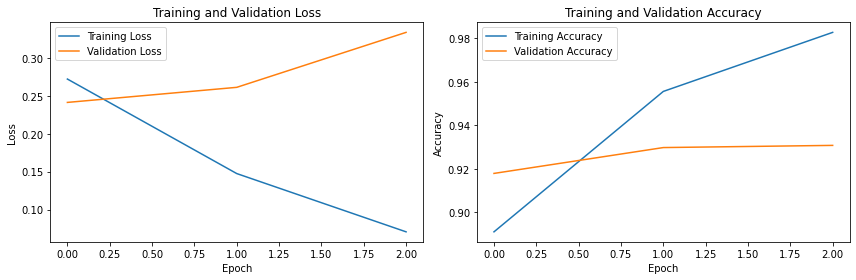

Model 4 Validation Accuracy: 0.9307


In [ ]:
# Model 4: Higher dropout
print("\n" + "="*50)
print("MODEL 4: HIGHER DROPOUT")


lr = 2e-5
batch_size = 16
max_len = 400
dropout = 0.5  # Changed

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

train_data = MovieReviewDataset(reviews=df_train['review'].to_numpy(), targets=df_train['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_data = MovieReviewDataset(reviews=df_valid['review'].to_numpy(), targets=df_valid['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

model4 = SentimentClassifierPooled(n_classes=2)
model4 = model4.to(device)
model4.dropout = nn.Dropout(dropout)
model4 = train_model(model4, train_loader, valid_loader, epochs=3, lr=lr)
final_acc4 = get_accuracy(model4, valid_loader)
print(f"Model 4 Validation Accuracy: {final_acc4:.4f}")

torch.save(model4.state_dict(), 'model4_sentiment_model.pth')



MODEL 5: SHORTER SEQUENCES
Testing: lr=2e-05, batch_size=16, max_len=256, dropout=0.3

Epoch 1/3
--------------------------------------------------


Training Loss: 0.3334, Accuracy: 0.8570
Validation Loss: 0.2265, Accuracy: 0.9086

Epoch 2/3
--------------------------------------------------
Training Loss: 0.1869, Accuracy: 0.9382
Validation Loss: 0.2881, Accuracy: 0.9135

Epoch 3/3
--------------------------------------------------
Training Loss: 0.1079, Accuracy: 0.9722
Validation Loss: 0.3839, Accuracy: 0.9145


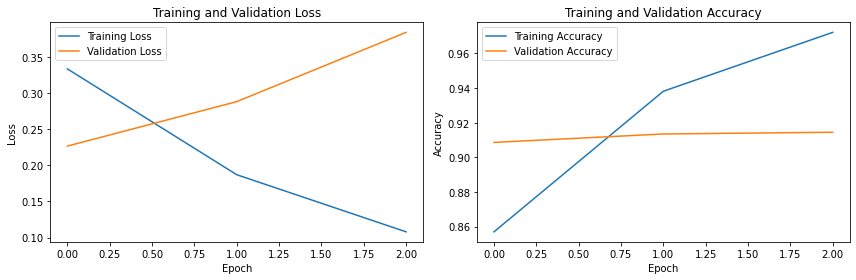

Model 5 Validation Accuracy: 0.9145


In [ ]:
# Model 5: Shorter sequences
print("\n" + "="*50)
print("MODEL 5: SHORTER SEQUENCES")
print("="*50)

lr = 2e-5
batch_size = 16
max_len = 256  # Changed
dropout = 0.3

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

train_data = MovieReviewDataset(reviews=df_train['review'].to_numpy(), targets=df_train['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_data = MovieReviewDataset(reviews=df_valid['review'].to_numpy(), targets=df_valid['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

model5 = SentimentClassifierPooled(n_classes=2)
model5 = model5.to(device)
model5.dropout = nn.Dropout(dropout)
model5 = train_model(model5, train_loader, valid_loader, epochs=3, lr=lr)
final_acc5 = get_accuracy(model5, valid_loader)
print(f"Model 5 Validation Accuracy: {final_acc5:.4f}")

torch.save(model5.state_dict(), 'model5_sentiment_model.pth')



MODEL 6: LOWER LEARNING RATE
Testing: lr=1e-05, batch_size=16, max_len=400, dropout=0.3

Epoch 1/3
--------------------------------------------------
Training Loss: 0.2776, Accuracy: 0.8855
Validation Loss: 0.1905, Accuracy: 0.9293

Epoch 2/3
--------------------------------------------------
Training Loss: 0.1651, Accuracy: 0.9471
Validation Loss: 0.2473, Accuracy: 0.9267

Epoch 3/3
--------------------------------------------------
Training Loss: 0.1080, Accuracy: 0.9707
Validation Loss: 0.2920, Accuracy: 0.9316


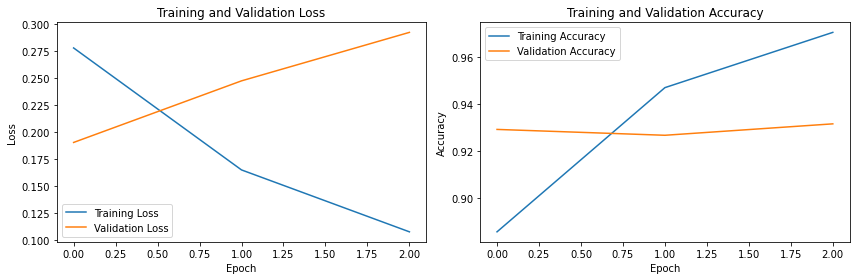

Model 6 Validation Accuracy: 0.9316


In [ ]:
# Model 6: Lower learning rate
print("\n" + "="*50)
print("MODEL 6: LOWER LEARNING RATE")
print("="*50)

lr = 1e-5  # Changed
batch_size = 16
max_len = 400
dropout = 0.3

print(f"Testing: lr={lr}, batch_size={batch_size}, max_len={max_len}, dropout={dropout}")

train_data = MovieReviewDataset(reviews=df_train['review'].to_numpy(), targets=df_train['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_data = MovieReviewDataset(reviews=df_valid['review'].to_numpy(), targets=df_valid['sentiment'].to_numpy(), tokenizer=tokenizer, max_len=max_len)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)

model6 = SentimentClassifierPooled(n_classes=2)
model6 = model6.to(device)
model6.dropout = nn.Dropout(dropout)
model6 = train_model(model6, train_loader, valid_loader, epochs=3, lr=lr)
final_acc6 = get_accuracy(model6, valid_loader)
print(f"Model 6 Validation Accuracy: {final_acc6:.4f}")


torch.save(model6.state_dict(), 'model6_sentiment_model.pth')




In [ ]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentimentClassifierPooled(n_classes=2)

# Load the saved weights
model.load_state_dict(torch.load('model1_sentiment_model.pth', map_location=device))

# Move model to device and set to evaluation mode
model = model.to(device)
model.eval()


SentimentClassifierPooled(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
# TO BE COMPLETED

test_data = MovieReviewDataset(
    reviews=df_test['review'].to_numpy(),
    targets=df_test['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_accuracy = get_accuracy(model,test_loader)
print(f"Final Test Accuracy: {test_accuracy:.4f}")


Final Test Accuracy: 0.9304


Epoch 1/15:
  Train Loss: 0.5249, Train Acc: 0.8458
  Valid Loss: 0.3995, Valid Acc: 0.8236
  ↳ New best validation loss: 0.3995
Epoch 2/15:
  Train Loss: 0.3737, Train Acc: 0.8748
  Valid Loss: 0.3655, Valid Acc: 0.8429
  ↳ New best validation loss: 0.3655
Epoch 3/15:
  Train Loss: 0.3313, Train Acc: 0.8893
  Valid Loss: 0.3604, Valid Acc: 0.8458
  ↳ New best validation loss: 0.3604
Epoch 4/15:
  Train Loss: 0.3029, Train Acc: 0.8992
  Valid Loss: 0.3553, Valid Acc: 0.8414
  ↳ New best validation loss: 0.3553
Epoch 5/15:
  Train Loss: 0.2751, Train Acc: 0.9186
  Valid Loss: 0.3705, Valid Acc: 0.8403
  ↳ No improvement for 1/3 epochs
Epoch 6/15:
  Train Loss: 0.2492, Train Acc: 0.9286
  Valid Loss: 0.3861, Valid Acc: 0.8410
  ↳ No improvement for 2/3 epochs
Epoch 7/15:
  Train Loss: 0.2201, Train Acc: 0.9312
  Valid Loss: 0.4342, Valid Acc: 0.8305
  ↳ No improvement for 3/3 epochs
Early stopping triggered at epoch 7


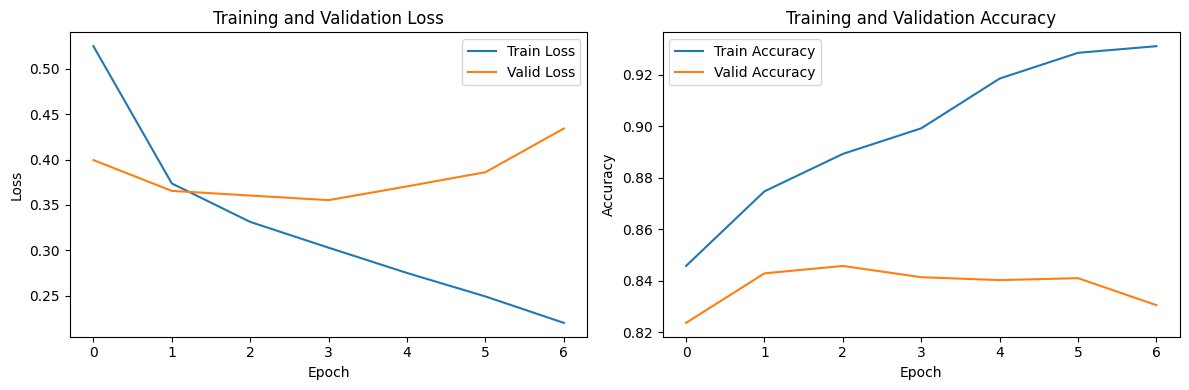

In [ ]:
final_model = SentimentRNN(
    vocab_size=1000,
    embedding_dim=128,
    hidden_dim=64,  # best_params['hidden_dim']
    n_layers=2,      # best_params['n_layers']
    dropout=0.5      # best_params['dropout']
)

# Train for 15 epochs with best learning rate
final_model = train_model(final_model, train_loader, valid_loader,
                         epochs=15, lr=0.0005)  # best_params['learning_rate']

In [ ]:
test_accuracy_LSTM = get_accuracy(final_model,test_loader)
print(f"Final Test Accuracy: {test_accuracy_LSTM:.4f}")

Final Test Accuracy: 0.8231


In [ ]:
import pandas as pd

# Replace these values with your actual accuracies
best_bert_train_acc = 0.9834
best_bert_val_acc   = 0.9356
best_bert_test_acc  = 0.9320

best_lstm_train_acc = 0.9312
best_lstm_val_acc   = 0.8305
best_lstm_test_acc  = 0.8231

# Create DataFrame
accuracy_df = pd.DataFrame({
    "Model": ["BERT (Best)", "LSTM (Best)"],
    "Training Accuracy": [best_bert_train_acc, best_lstm_train_acc],
    "Validation Accuracy": [best_bert_val_acc, best_lstm_val_acc],
    "Test Accuracy": [best_bert_test_acc, best_lstm_test_acc]
})

# Display the DataFrame
print(accuracy_df)

         Model  Training Accuracy  Validation Accuracy  Test Accuracy
0  BERT (Best)             0.9834               0.9356         0.9320
1  LSTM (Best)             0.9312               0.8305         0.8231


In [ ]:
MAX_LEN = 400
BATCH_SIZE = 16

# Training data
train_data = MovieReviewDataset(
    reviews=df_train['review'].to_numpy(),
    targets=df_train['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

train_data_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)#modify num_works as needed

# Validation data
valid_data = MovieReviewDataset(
    reviews=df_valid['review'].to_numpy(),
    targets=df_valid['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

valid_data_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Test data
test_data = MovieReviewDataset(
    reviews=df_test['review'].to_numpy(),
    targets=df_test['sentiment'].to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

test_data_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:


from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

def get_detailed_metrics(model, data_loader):
    """Get precision, recall, f1-score for a model"""
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    precision = precision_score(all_targets, all_predictions)
    recall = recall_score(all_targets, all_predictions)
    f1 = f1_score(all_targets, all_predictions)

    return precision, recall, f1, all_predictions, all_targets

# Get metrics for best BERT model
print("=== BERT MODEL DETAILED METRICS ===")
bert_test_precision, bert_test_recall, bert_test_f1, bert_preds, bert_targets = get_detailed_metrics(model, test_data_loader)

print(f"BERT Test Precision: {bert_test_precision:.4f}")
print(f"BERT Test Recall: {bert_test_recall:.4f}")
print(f"BERT Test F1-Score: {bert_test_f1:.4f}")



=== BERT MODEL DETAILED METRICS ===
BERT Test Precision: 0.9264
BERT Test Recall: 0.9359
BERT Test F1-Score: 0.9311


In [ ]:
# Training metrics
bert_train_precision, bert_train_recall, bert_train_f1, bert_train_preds, bert_train_targets = get_detailed_metrics(model, train_data_loader)
print(f"BERT Training Precision: {bert_train_precision:.4f}")
print(f"BERT Training Recall: {bert_train_recall:.4f}")
print(f"BERT Training F1-Score: {bert_train_f1:.4f}")

# Validation metrics
bert_valid_precision, bert_valid_recall, bert_valid_f1, bert_valid_preds, bert_valid_targets = get_detailed_metrics(model, valid_data_loader)
print(f"\nBERT Validation Precision: {bert_valid_precision:.4f}")
print(f"BERT Validation Recall: {bert_valid_recall:.4f}")
print(f"BERT Validation F1-Score: {bert_valid_f1:.4f}")

BERT Training Precision: 0.9924
BERT Training Recall: 0.9945
BERT Training F1-Score: 0.9935

BERT Validation Precision: 0.9327
BERT Validation Recall: 0.9347
BERT Validation F1-Score: 0.9337


In [ ]:
def get_detailed_metrics_lstm(model, data_loader):
    """Get precision, recall, f1-score for LSTM model"""
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # LSTM forward pass (adjust based on your LSTM model architecture)
            outputs, _ = model(batch_x)

            # Get predictions - handle both binary and multi-class outputs
            if outputs.shape[1] == 1:  # Binary classification with 1 output
                predicted = (torch.sigmoid(outputs) > 0.5).long().squeeze()
            else:  # Multi-class with 2+ outputs
                _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    precision = precision_score(all_targets, all_predictions, zero_division=0)
    recall = recall_score(all_targets, all_predictions, zero_division=0)
    f1 = f1_score(all_targets, all_predictions, zero_division=0)

    return precision, recall, f1, all_predictions, all_targets


# Training metrics
lstm_train_precision, lstm_train_recall, lstm_train_f1, train_preds, train_targets = get_detailed_metrics_lstm(final_model, train_loader)
print(f"LSTM Training Precision: {lstm_train_precision:.4f}")
print(f"LSTM Training Recall: {lstm_train_recall:.4f}")
print(f"LSTM Training F1-Score: {lstm_train_f1:.4f}")

# Validation metrics
lstm_valid_precision, lstm_valid_recall, lstm_valid_f1, valid_preds, valid_targets = get_detailed_metrics_lstm(final_model, valid_loader)
print(f"\nLSTM Validation Precision: {lstm_valid_precision:.4f}")
print(f"LSTM Validation Recall: {lstm_valid_recall:.4f}")
print(f"LSTM Validation F1-Score: {lstm_valid_f1:.4f}")

# Test metrics
lstm_test_precision, lstm_test_recall, lstm_test_f1, test_preds, test_targets = get_detailed_metrics_lstm(final_model, test_loader)
print(f"\nLSTM Test Precision: {lstm_test_precision:.4f}")
print(f"LSTM Test Recall: {lstm_test_recall:.4f}")
print(f"LSTM Test F1-Score: {lstm_test_f1:.4f}")


LSTM Training Precision: 0.8961
LSTM Training Recall: 0.9752
LSTM Training F1-Score: 0.9340

LSTM Validation Precision: 0.7957
LSTM Validation Recall: 0.8892
LSTM Validation F1-Score: 0.8399

LSTM Test Precision: 0.7862
LSTM Test Recall: 0.8904
LSTM Test F1-Score: 0.8351


In [ ]:
comparison_data = []

# Add BERT metrics
comparison_data.append({
    'Model': 'BERT',
    'Dataset': 'Training',
    'Precision': bert_train_precision,
    'Recall': bert_train_recall,
    'F1-Score': bert_train_f1
})

comparison_data.append({
    'Model': 'BERT',
    'Dataset': 'Validation',
    'Precision': bert_valid_precision,
    'Recall': bert_valid_recall,
    'F1-Score': bert_valid_f1
})

comparison_data.append({
    'Model': 'BERT',
    'Dataset': 'Test',
    'Precision': bert_test_precision,
    'Recall': bert_test_recall,
    'F1-Score': bert_test_f1
})

# Add LSTM metrics
comparison_data.append({
    'Model': 'LSTM',
    'Dataset': 'Training',
    'Precision': lstm_train_precision,
    'Recall': lstm_train_recall,
    'F1-Score': lstm_train_f1
})

comparison_data.append({
    'Model': 'LSTM',
    'Dataset': 'Validation',
    'Precision': lstm_valid_precision,
    'Recall': lstm_valid_recall,
    'F1-Score': lstm_valid_f1
})

comparison_data.append({
    'Model': 'LSTM',
    'Dataset': 'Test',
    'Precision': lstm_test_precision,
    'Recall': lstm_test_recall,
    'F1-Score': lstm_test_f1
})

# Create DataFrame
results_df = pd.DataFrame(comparison_data)

# Display the DataFrame
print(results_df.round(4))


  Model     Dataset  Precision  Recall  F1-Score
0  BERT    Training     0.9924  0.9945    0.9935
1  BERT  Validation     0.9327  0.9348    0.9337
2  BERT        Test     0.9264  0.9359    0.9311
3  LSTM    Training     0.8961  0.9752    0.9340
4  LSTM  Validation     0.7957  0.8892    0.8399
5  LSTM        Test     0.7862  0.8904    0.8351


In [ ]:
count = 0
for i, (actual, predicted) in enumerate(zip(bert_targets, bert_preds)):
    if actual != predicted:
        count += 1
        print(f"\nExample {count}:")
        print(f"True: {'Positive' if actual == 1 else 'Negative'}")
        print(f"Predicted: {'Positive' if predicted == 1 else 'Negative'}")
        print(f"Review: {df_test.iloc[i]['review']}")
        print("-" * 50)

        if count >= 2:
            break


Example 1:
True: Positive
Predicted: Negative
Review: I watched both Bourne Identity and Bourne Supremacy on DVD before seeing this in the theater. I'd been waiting for this since before they started filming. I wasn't disappointed.<br /><br />Minor spoilers below- <br /><br />Overall it was good, but it also lacked the continuity of the first two. Identity and Supremacy both flowed gracefully between adrenaline rush action to introspective drama. This movie felt choppy at times. The plot-building down-times were slightly too drawn out. That caused the following action to feel too frenetic.<br /><br />Camera: Speaking of frenetic, the trademark Greengrass shaky cam was present and very annoying to me. I know its has been talked/whined about to nausea on the message board, but it doesn't mean it's not relevant. All the martial arts training the actors went through was totally wasted. The ridiculous camera cuts and wiggling camera ruined most of the fighting in the movie. It is a cheap, 

In [ ]:
def predict_sentiment_bert(review_text, model, tokenizer, max_len=400):
    model.eval()

    # Tokenize input
    encoding = tokenizer.encode_plus(
        review_text,
        add_special_tokens=True,
        max_length=max_len,
        return_token_type_ids=False,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
        truncation=True
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, prediction = torch.max(outputs, dim=1)

    label = "positive" if prediction.item() == 1 else "negative"
    return label


In [ ]:
def predict_sentiment_lstm(review_text, model, stoi, seq_len=500):
    model.eval()

    # Tokenize review
    tokens = [stoi.get(word.lower(), 0) for word in review_text.split()]  # 0 = unknown

    # Pad or truncate
    if len(tokens) < seq_len:
        tokens = tokens + [0] * (seq_len - len(tokens))
    else:
        tokens = tokens[:seq_len]

    # Convert to tensor
    input_tensor = torch.tensor(tokens).unsqueeze(0).to(device)  # shape [1, seq_len]

    with torch.no_grad():
        output, _ = model(input_tensor)
        # For binary classification: output_dim=1, apply sigmoid
        prob = torch.sigmoid(output).item()
        label = "positive" if prob >= 0.5 else "negative"

    return label


In [ ]:
import pandas as pd

# Sample 6 reviews (3 positive, 3 negative)
reviews =  [
    "I haven't been this invested into a movie since I saw the Last Samurai in theaters. So good.",  # positive
    "I now believe in Lisan Al Gaib. To this day, the BEST in-cinema experience I’ve ever had",                  # positive
    "One of the most brilliant science fiction films ever made and a great improvement of the 1984 film adaptation.",            # positive
    "Extremely boring. Tried watching it multiple times, could never finish.",                    # negative
    "Jush trashheap or a movie series so far with two main characters being unwatchable.",           # negative
    "Read the books instead. While Dune part one was acceptable in comparison with the source material, this second part is too dumbed down and silly.",         # negative
]

# Actual sentiments
actual_sentiments = ["positive", "positive", "positive", "negative", "negative", "negative"]

# Create DataFrame
df_reviews = pd.DataFrame({
    "review_text": reviews,
    "actual_sentiment": actual_sentiments
})

# Run predictions
df_reviews['lstm_pred'] = df_reviews['review_text'].apply(lambda x: predict_sentiment_lstm(x, final_model, stoi))
df_reviews['bert_pred'] = df_reviews['review_text'].apply(lambda x: predict_sentiment_bert(x, model, tokenizer))

# Display DataFrame
print(df_reviews)

                                         review_text actual_sentiment  \
0  I haven't been this invested into a movie sinc...         positive   
1  I now believe in Lisan Al Gaib. To this day, t...         positive   
2  One of the most brilliant science fiction film...         positive   
3  Extremely boring. Tried watching it multiple t...         negative   
4  Jush trashheap or a movie series so far with t...         negative   
5  Read the books instead. While Dune part one wa...         negative   

  lstm_pred bert_pred  
0  positive  positive  
1  positive  positive  
2  positive  positive  
3  positive  negative  
4  positive  negative  
5  positive  negative  
